# Cluster selection — Phase 1 (GBDT)

**Problem.** Vertex-timing error in Z+jets is dominated by *cluster selection*, not clustering:
a cluster within 60 ps of truth exists in ~87% of events, but the best hand-made score
(TRKPTZ) picks it only ~62% of the time. Hand-designed reweightings of the WAVeS jet term
(LOJO / JETCAP / KERNEL) all failed — LOJO changed the decision on ~4700 recoverable events
and was right 47.7% of the time, i.e. a coin flip. So we learn the selector instead.

**Framing.** This is *ranking within an event*, not per-cluster classification. That distinction
matters: an earlier attempt at absolute per-cluster "is this cluster trustworthy?" failed, because
a confidently-wrong cluster looks identical to a right one in reco-only features. Relative
comparison inside one event is a different — and easier — question.

**Constraint.** No `lightgbm`/`xgboost` in this kernel, so there is no listwise objective available.
We use `HistGradientBoosting` (NaN-native) with **within-event context features** to inject the
relative information, and take argmax/argmin *within event* at inference. Three formulations:

| formulation | target | pick |
|---|---|---|
| **A** | binary: is the truth-closest cluster | argmax proba |
| **B** | binary: within 60 ps of truth | argmax proba |
| **C** | regress log1p(&#124;Δt&#124;) | **argmin** prediction |

**Figure of merit is the physics metric, not AUC**: core fraction (selected cluster within
±60 ps of truth), reported against the TRKPTZ baseline and the oracle ceiling.

## 1. Setup

In [1]:
import glob, os, warnings
import numpy as np, pandas as pd, uproot
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# Optional backends from the vtx venv. Guarded so the notebook still runs on the
# stock kernel, just without xgboost/lightgbm sections.
try:
    import xgboost as xgb
    HAVE_XGB = True
except ImportError:
    HAVE_XGB = False
try:
    import lightgbm as lgb
    HAVE_LGB = True
except ImportError:
    HAVE_LGB = False
print(f"xgboost: {xgb.__version__ if HAVE_XGB else 'MISSING'}   "
      f"lightgbm: {lgb.__version__ if HAVE_LGB else 'MISSING'}"
      + ("" if (HAVE_XGB and HAVE_LGB) else "   <- switch to the Python (vtx) kernel"))
warnings.filterwarnings("ignore")

# --- where the exporter's ROOT files live -----------------------------------
# condor writes <repo>/<sample>/<sample>_training.root; the local run writes
# figs/hists/training.root. Adjust SEARCH_DIRS if you staged them elsewhere.
SEARCH_DIRS = [".", "..", "../..", "figs/hists", "../figs/hists"]
SAMPLES     = ["vbf", "zjets", "dijet"]

PASS_PS   = 60.0     # the physics window (PASS_SIGMA in clustering_constants.h)
EVT       = ["sample_id", "event_num"]   # ranking group key
RANDOM    = 0

SAMPLE_NAME = {0.0: "vbf", 1.0: "zjets", 2.0: "dijet", 3.0: "local"}

def find_files():
    hits = {}
    for d in SEARCH_DIRS:
        for s in SAMPLES:
            for p in glob.glob(os.path.join(d, s, f"{s}_training.root")) + \
                     glob.glob(os.path.join(d, f"{s}_training.root")):
                hits.setdefault(s, os.path.abspath(p))
        for p in glob.glob(os.path.join(d, "training.root")):
            hits.setdefault("local", os.path.abspath(p))
    return hits

FILES = find_files()
for k, v in FILES.items():
    print(f"  found {k:6s} -> {v}")
if not FILES:
    print("\\n!! No training ROOT files found. Run:  ./export_training_data --sample=<s>")

xgboost: 3.3.0   lightgbm: 4.7.0
  found vbf    -> /home/mcardiff/project/vertex_timing/figs/hists/vbf_training.root
  found zjets  -> /home/mcardiff/project/vertex_timing/figs/hists/zjets_training.root
  found dijet  -> /home/mcardiff/project/vertex_timing/figs/hists/dijet_training.root

## 2. Load

In [2]:
def load(files):
    parts = []
    for name, path in files.items():
        df = uproot.open(path)["clusters"].arrays(library="pd")
        parts.append(df)
        print(f"  {name:6s} {len(df):>8,} cluster rows   "
              f"{df.groupby(EVT).ngroups:>7,} events   ({path})")
    return pd.concat(parts, ignore_index=True)

df = load(FILES)
df["abs_dt"] = df["delta_t"].abs()
print(f"\ntotal {len(df):,} rows / {df.groupby(EVT).ngroups:,} events / {df.shape[1]} columns")

  vbf    3,487,533 cluster rows   620,101 events   (/home/mcardiff/project/vertex_timing/figs/hists/vbf_training.root)  zjets   378,296 cluster rows    67,074 events   (/home/mcardiff/project/vertex_timing/figs/hists/zjets_training.root)  dijet   545,553 cluster rows    94,605 events   (/home/mcardiff/project/vertex_timing/figs/hists/dijet_training.root)
total 4,411,382 rows / 781,780 events / 96 columns

## 3. Labels and baselines

Labels come from `delta_t` (cluster time − truth HS time), which is the **target**, never a feature.
`is_best` = the truth-closest cluster in the event; `within60` = inside the physics window
(multi-positive — several clusters can qualify).

In [3]:
g = df.groupby(EVT, sort=False)["abs_dt"]
df["is_best"]  = (df["abs_dt"] == g.transform("min")).astype(int)
df["within60"] = (df["abs_dt"] < PASS_PS).astype(int)
# an event is RECOVERABLE if any cluster is inside the window; a "win" on an
# unrecoverable event is luck, so we report both inclusive and conditional numbers
df["recoverable"] = (g.transform("min") < PASS_PS).astype(int)

def select_metric(frame, col, higher_is_better=True):
    """Pick one cluster per event by `col`, return (core fraction, median |dt|)."""
    s = frame[col]
    s = s.fillna(-np.inf if higher_is_better else np.inf)
    idx = s.groupby([frame[c] for c in EVT], sort=False)
    idx = idx.idxmax() if higher_is_better else idx.idxmin()
    sel = frame.loc[idx.to_numpy()]
    return 100.0 * (sel["abs_dt"] < PASS_PS).mean(), sel["abs_dt"].median()

def report(frame, rows, title):
    print(f"\n{title}   ({frame.groupby(EVT).ngroups:,} events)")
    print(f"  {'selector':26s} {'core<60ps':>10s} {'median|dt|':>11s}")
    print("  " + "-" * 50)
    for name, col, hib in rows:
        cf, md_ = select_metric(frame, col, hib)
        print(f"  {name:26s} {cf:9.1f}% {md_:10.1f} ps")

BASELINES = [("oracle (truth-closest)", "abs_dt", False),
             ("TRKPTZ", "trkptz_score", True),
             ("WAVeS",  "waves_score",  True),
             ("sumpt",  "sumpt",        True)]
report(df, BASELINES, "ALL SAMPLES")
for sid, sub in df.groupby("sample_id"):
    report(sub, BASELINES, f"sample = {SAMPLE_NAME.get(sid, sid)}")


ALL SAMPLES   (781,780 events)
  selector                    core<60ps  median|dt|
  --------------------------------------------------  oracle (truth-closest)          97.7%       11.1 ps  TRKPTZ                          87.3%       12.2 ps  WAVeS                           87.5%       12.2 ps  sumpt                           85.9%       12.4 ps
sample = vbf   (620,101 events)
  selector                    core<60ps  median|dt|
  --------------------------------------------------  oracle (truth-closest)          98.2%       10.7 ps  TRKPTZ                          90.1%       11.5 ps  WAVeS                           90.7%       11.4 ps  sumpt                           89.1%       11.6 ps

sample = zjets   (67,074 events)
  selector                    core<60ps  median|dt|
  --------------------------------------------------
  oracle (truth-closest)          92.5%       17.8 ps
  TRKPTZ                          62.0%       31.3 ps
  WAVeS                           60.0%       33.8 ps  

## 4. Features

Three things happen here:

1. **Leakage guard** — every `truth_*` column, `delta_t`/`abs_dt` and the derived labels are
   dropped from `X`. `sample_id` is dropped too, so the cross-topology test in §8 is honest.

   > ⚠️ **The prefix test alone is not sufficient on older files.** The exporter only started
   > writing `nHGTDPrimaryHits` under a `truth_` prefix in `e507e76`; any `*_training.root`
   > produced before that re-export still carries the bare name `mean_nhgtd_primary`, which
   > `startswith("truth_")` cannot see. `TRUTH_ALIASES` below lists the pre-rename names so the
   > guard is correct for **both** vintages, and the cell prints a warning when it fires.
   > A closing `assert` fails loudly rather than training on a truth column.

2. **Degenerate columns** are detected and removed automatically (all-NaN or constant). This
   catches the known ones without hard-coding: `frac_valid_time`/`n_valid_time`/`sumpt_valid_time`
   are degenerate by construction (clustering already requires valid times), `mean/min_quality`
   is constant in these samples, and the lepton block is empty outside Z+jets.
3. **By-design exclusions** (`EXCLUDE_BY_DESIGN`) — features that are legitimate reco but that we
   refuse on scientific grounds:
   - the **HGTD block** (`hgtd_time`, `hgtd_valid`, `hgtd_time_res`, `dt_cluster_to_hgtd`) all derive
     from `RecoVtx_time`, i.e. the *old algorithm's output*. The point of this work is to replace
     that algorithm, so depending on it would be circular. Measured cost: ~0.5 points.
     `dt_cluster_to_hgtd` has ρ = **+0.96** with `abs_dt` — it is very nearly the target.
   - `nHGTDPrimaryHits` — **confirmed truth, and confirmed label leakage.** Athena builds it from
     a per-hit `m_isprime` flag, commented *"keep which of the hits associated in reco were
     primary hits (truth info!)"*. It counts how many of a track's HGTD hits genuinely came from
     that track's own truth particle — which is *directly* a statement about whether the track's
     **time** is right, and therefore about the label.

     > **Two earlier arguments that it was harmless were both wrong, and are worth recording
     > because the failure modes are generic:**
     >
     > 1. *"Correlation with `truth_is_hs` is only +0.09."* Wrong target. The label is time
     >    accuracy, not HS-ness. Measured on the local VBF file: ρ = −0.065 with `truth_purity`
     >    but **+0.21 with `is_best`, +0.22 with `within60`, and −0.44 with `abs_dt`**. It is
     >    nearly orthogonal to the quantity I tested and strongly aligned with the actual label.
     > 2. *"Drop-column ablation says its contribution is exactly 0.0."* Right test, wrong
     >    sample. On VBF it **is** 0.0 (92.5% with and without, reproduced) because VBF has only
     >    ~8 points of headroom and `sumpt`/`is_max_trkptz` already cover it. On Z+jets, where
     >    TRKPTZ delivers 62% against a 92% ceiling, no legitimate feature covers that ground and
     >    the model leans on the truth column hard: **80%+ with it, 66% without.** A pooled or
     >    VBF-only ablation cannot see this — hence the per-sample ablation in §9b.

4. **Within-event normalization** — the load-bearing step given we have no listwise loss. For a
   curated set of features we add `_ratio_to_max` and `_rank` *within the event*, which is what
   lets a per-cluster model express "best of what's available here".## 4. Features

Three things happen here:

1. **Leakage guard** — every `truth_*` column, `delta_t`/`abs_dt` and the derived labels are
   dropped from `X`. `sample_id` is dropped too, so the cross-topology test in §8 is honest.

   > ⚠️ **The prefix test alone is not sufficient on older files.** The exporter only started
   > writing `nHGTDPrimaryHits` under a `truth_` prefix in `e507e76`; any `*_training.root`
   > produced before that re-export still carries the bare name `mean_nhgtd_primary`, which
   > `startswith("truth_")` cannot see. `TRUTH_ALIASES` below lists the pre-rename names so the
   > guard is correct for **both** vintages, and the cell prints a warning when it fires.
   > A closing `assert` fails loudly rather than training on a truth column.

2. **Degenerate columns** are detected and removed automatically (all-NaN or constant). This
   catches the known ones without hard-coding: `frac_valid_time`/`n_valid_time`/`sumpt_valid_time`
   are degenerate by construction (clustering already requires valid times), `mean/min_quality`
   is constant in these samples, and the lepton block is empty outside Z+jets.
3. **By-design exclusions** (`EXCLUDE_BY_DESIGN`) — features that are legitimate reco but that we
   refuse on scientific grounds:
   - the **HGTD block** (`hgtd_time`, `hgtd_valid`, `hgtd_time_res`, `dt_cluster_to_hgtd`) all derive
     from `RecoVtx_time`, i.e. the *old algorithm's output*. The point of this work is to replace
     that algorithm, so depending on it would be circular. Measured cost: ~0.5 points.
     `dt_cluster_to_hgtd` has ρ = **+0.96** with `abs_dt` — it is very nearly the target.
   - `nHGTDPrimaryHits` — **confirmed truth, and confirmed label leakage.** Athena builds it from
     a per-hit `m_isprime` flag, commented *"keep which of the hits associated in reco were
     primary hits (truth info!)"*. It counts how many of a track's HGTD hits genuinely came from
     that track's own truth particle — which is *directly* a statement about whether the track's
     **time** is right, and therefore about the label.

     > **Two earlier arguments that it was harmless were both wrong, and are worth recording
     > because the failure modes are generic:**
     >
     > 1. *"Correlation with `truth_is_hs` is only +0.09."* Wrong target. The label is time
     >    accuracy, not HS-ness. Measured on the local VBF file: ρ = −0.065 with `truth_purity`
     >    but **+0.21 with `is_best`, +0.22 with `within60`, and −0.44 with `abs_dt`**. It is
     >    nearly orthogonal to the quantity I tested and strongly aligned with the actual label.
     > 2. *"Drop-column ablation says its contribution is exactly 0.0."* Right test, wrong
     >    sample. On VBF it **is** 0.0 (92.5% with and without, reproduced) because VBF has only
     >    ~8 points of headroom and `sumpt`/`is_max_trkptz` already cover it. On Z+jets, where
     >    TRKPTZ delivers 62% against a 92% ceiling, no legitimate feature covers that ground and
     >    the model leans on the truth column hard: **80%+ with it, 66% without.** A pooled or
     >    VBF-only ablation cannot see this — hence the per-sample ablation in §9b.

4. **Within-event normalization** — the load-bearing step given we have no listwise loss. For a
   curated set of features we add `_ratio_to_max` and `_rank` *within the event*, which is what
   lets a per-cluster model express "best of what's available here".

In [4]:
LABELS = ["is_best", "within60", "recoverable"]
# Ordering guard: this cell must run AFTER §3, which creates the label columns.
# If it runs first they are simply absent from df -- they cannot leak into feat,
# but the "held out" count silently drops and the guard is then passing by
# accident rather than by construction. (Observed: run 4 executed §4 at In[3]
# and §3 at In[4].)
assert all(c in df.columns for c in LABELS), \
    f"run \u00a73 first -- missing {[c for c in LABELS if c not in df.columns]}"

LEAK = [c for c in df.columns if c.startswith("truth_")] + \
       ["delta_t", "abs_dt"] + LABELS
IDS  = ["event_num", "cluster_idx", "sample_id", "weight"]

# Pre-rename aliases. The exporter emits these under the truth_ prefix as of
# e507e76, but a ROOT file written BEFORE that re-export still has the old bare
# name, which the prefix test above cannot catch -- and e507e76 also removed the
# manual exclusion, so on an old file the column silently re-enters the features.
# Listing the old names keeps the guard correct for both vintages; on a
# re-exported file they simply match nothing. Safe to delete only once every
# training file on disk is post-rename.
TRUTH_ALIASES = ["mean_nhgtd_primary", "nhgtd_primary"]
_stale = sorted(set(TRUTH_ALIASES) & set(df.columns))
if _stale:
    print("!! PRE-RENAME FILE: " + ", ".join(_stale) + " present under the old bare name.")
    print("   Excluded via TRUTH_ALIASES (the truth_ prefix test does not see them).")
    print("   Re-run util/export_training_data.cxx to emit them truth_-prefixed.\n")
LEAK += TRUTH_ALIASES

# Legitimate reco, but excluded deliberately -- see the notes above. Flip
# USE_HGTD_FEATURES to True only to quantify what the old-algorithm prior is worth.
USE_HGTD_FEATURES = False
HGTD_BLOCK = ["hgtd_time", "hgtd_valid", "hgtd_time_res", "dt_cluster_to_hgtd", "mean_nhgtd_primary"]
# (mean_nhgtd_primary is no longer listed here: the exporter now writes it as
#  truth_mean_nhgtd_primary, so the truth_ guard above catches it automatically.)
EXCLUDE_BY_DESIGN = [] if USE_HGTD_FEATURES else list(HGTD_BLOCK)

# Curated list for within-event normalization: continuous, physically meaningful,
# and plausibly comparative. (Normalizing all ~90 would triple the width for little gain.)
NORMALIZE = ["sumpt", "sumpt2", "maxpt", "n_tracks", "cluster_time_sigma",
             "time_chi2_ndf", "delta_z_resunits", "z_chi2_ndf", "mean_nhgtd",
             "trkptz_score", "waves_score", "frac_pt_in_fwdjet", "lead_pt_frac",
             "dz_to_lepton_signif", "sumpt_in_fwdjet"]

def add_event_context(frame):
    frame = frame.copy()
    gb = frame.groupby(EVT, sort=False)
    for c in NORMALIZE:
        if c not in frame.columns:
            continue
        mx = gb[c].transform("max")
        frame[f"{c}_ratio_to_max"] = np.where(np.abs(mx) > 0, frame[c] / mx, np.nan)
        frame[f"{c}_rank"] = gb[c].rank(ascending=False, method="min")
    return frame

df = add_event_context(df)

DROP = set(LEAK) | set(IDS) | set(EXCLUDE_BY_DESIGN)
feat = [c for c in df.columns if c not in DROP]
# auto-drop degenerate columns (evaluated on the full set)
degen = [c for c in feat
         if df[c].isna().all() or df[c].nunique(dropna=True) <= 1]
feat = [c for c in feat if c not in degen]

# Fail loudly rather than train on a truth column: cheap, and the two mechanisms
# above (prefix + alias) are exactly the kind of thing that rots when the schema moves.
_bad = [c for c in feat if c.startswith("truth_") or c in set(TRUTH_ALIASES)]
assert not _bad, f"TRUTH LEAKED INTO FEATURES: {_bad}"

print(f"dropped {len(degen)} degenerate columns:")
for c in degen: print("   ", c)
print(f"\nexcluded by design: {sorted(set(EXCLUDE_BY_DESIGN) & set(df.columns))}")
print(f"truth/label columns held out: {len(set(LEAK) & set(df.columns))}")
print(f"{len(feat)} features -> X")

!! PRE-RENAME FILE: mean_nhgtd_primary present under the old bare name.
   Excluded via TRUTH_ALIASES (the truth_ prefix test does not see them).
   Re-run util/export_training_data.cxx to emit them truth_-prefixed.
dropped 3 degenerate columns:
    frac_valid_time
    mean_quality
    min_quality

excluded by design: ['dt_cluster_to_hgtd', 'hgtd_time', 'hgtd_time_res', 'hgtd_valid', 'mean_nhgtd_primary']
truth/label columns held out: 9
107 features -> X

## 5. Split

Split **by event**, never by row — two clusters from the same event must not straddle
train/test, or the model sees the answer. Events are the effective sample size here
(~N_events, not N_rows).

In [5]:
rng = np.random.default_rng(RANDOM)
ev  = df[EVT].drop_duplicates().reset_index(drop=True)
ev["fold"] = rng.random(len(ev))
df2 = df.merge(ev, on=EVT, how="left")
train = df2[df2.fold <  0.7].copy()
test  = df2[df2.fold >= 0.7].copy()
print(f"train {train.groupby(EVT).ngroups:,} events / {len(train):,} rows")
print(f"test  {test.groupby(EVT).ngroups:,} events / {len(test):,} rows")

train 546,638 events / 3,083,236 rows
test  235,142 events / 1,328,146 rows

## 6. Train — formulations A, B, C

`HistGradientBoosting` handles NaN natively, which matters: `time_chi2_ndf` is NaN for the
~32% of clusters with a single timed track, and `hgtd_*` is NaN wherever `RecoVtx_time` is
missing (~8% in VBF, ~55% in Z+jets). **Never impute those with 0** — 0.0 is a legitimate time.

In [6]:
# =============================== BACKEND ====================================
# Two GBDT backends behind one interface. sklearn's HistGradientBoosting was the
# only option before the vtx venv; xgboost is now the default for three reasons:
#
#   1. COLUMN SUBSAMPLING -- the real one. The per-sample ablation (§9b) showed
#      extreme redundancy: no feature block is worth >0.5 pts, and dropping all
#      11 jet-association features costs 0.1. colsample_by* is the standard
#      regularizer for precisely that regime, and sklearn's HistGradientBoosting
#      has no column-subsampling parameter at all.
#   2. Speed: hist + n_jobs=-1, which matters now that §9b fits 5+ models.
#   3. One library for these pointwise models and §12's ranker.
#
# Runs 1-4 were all sklearn. Set BACKEND="sklearn" to reproduce them exactly.
BACKEND = "xgb" if HAVE_XGB else "sklearn"

COMMON = dict(max_iter=2000, learning_rate=0.06, max_leaf_nodes=31,
              min_samples_leaf=50, l2_regularization=1.0,
              early_stopping=True, validation_fraction=0.15,
              random_state=RANDOM)

# NOTE min_child_weight is NOT min_samples_leaf. It is a sum of hessians, and for
# logloss the per-row hessian is p(1-p) <= 0.25, so 50 would mean 200+ rows per
# leaf -- far stricter than sklearn's 50. 5 is the closer analogue.
XGB_COMMON = dict(n_estimators=2000, learning_rate=0.06,
                  max_leaves=31, max_depth=0, grow_policy="lossguide",
                  min_child_weight=5, reg_lambda=1.0,
                  subsample=0.8, colsample_bytree=0.8,
                  tree_method="hist", n_jobs=-1, random_state=RANDOM,
                  early_stopping_rounds=50)

# Early stopping validates on an EVENT-DISJOINT slice carved out of train.
# sklearn's validation_fraction splits ROWS at random, so two clusters of the same
# event can straddle its internal split; `fold` is per-event, so this cannot.
# Affects only where training stops, never the reported test metric -- but free.
VAL_LO = 0.60
def split_tv(frame):
    return frame[frame.fold < VAL_LO], frame[frame.fold >= VAL_LO]

# Optional: upweight the smaller samples so zjets (8.6% of events but where 26 of
# the ~30 available points live) is not drowned by VBF. The transfer matrix says
# the gain is ~0.2, so off by default.
BALANCE_SAMPLES = False
def sample_weights(frame):
    if not BALANCE_SAMPLES:
        return None
    n = frame.groupby("sample_id")["sample_id"].transform("size")
    return (len(frame) / (frame["sample_id"].nunique() * n)).to_numpy()

SK = (HistGradientBoostingClassifier, HistGradientBoostingRegressor)

def gbdt(task="clf", backend=None, **over):
    """Unfitted estimator for the active backend. task: 'clf' | 'reg'."""
    b = backend or BACKEND
    if b == "xgb":
        return (xgb.XGBClassifier if task == "clf" else xgb.XGBRegressor)(
            **{**XGB_COMMON, **over})
    return (HistGradientBoostingClassifier if task == "clf"
            else HistGradientBoostingRegressor)(**{**COMMON, **over})

def _target(frame, y):
    return y(frame) if callable(y) else frame[y]

def fit_gbdt(m, cols, y, frame, weights=True):
    """Fit on `frame`, early-stopping on its event-disjoint validation slice.
    `y` is a column name or a callable frame -> target."""
    trn, val = split_tv(frame)
    w = sample_weights(trn) if weights else None
    if isinstance(m, SK):
        m.fit(trn[cols], _target(trn, y), sample_weight=w)
    else:
        m.fit(trn[cols], _target(trn, y), sample_weight=w,
              eval_set=[(val[cols], _target(val, y))], verbose=False)
    return m

def proba(m, X):
    return m.predict_proba(X)[:, 1]

def n_trees(m):
    return getattr(m, "n_iter_", None) if isinstance(m, SK) else m.best_iteration

# ============================== FORMULATIONS ================================
models = {}

mA = fit_gbdt(gbdt("clf"), feat, "is_best", train)
test["scoreA"] = proba(mA, test[feat]); models["A is_best"] = mA

mB = fit_gbdt(gbdt("clf"), feat, "within60", train)
test["scoreB"] = proba(mB, test[feat]); models["B within60"] = mB

# C -- regress log1p(|dt|); log compresses a very long tail. Pick the MINIMUM.
mC = fit_gbdt(gbdt("reg"), feat, lambda f: np.log1p(f["abs_dt"]), train)
test["scoreC"] = mC.predict(test[feat]); models["C reg log|dt|"] = mC

print(f"backend: {BACKEND}")
for k, m in models.items():
    print(f"  {k:16s} trees used: {n_trees(m)}")

# ---- is the backend switch neutral-or-better? ------------------------------
# Runs 1-4 were sklearn; without this the numbers silently become incomparable.
# Fits formulation B both ways on identical data. Set False once you've seen it.
BACKEND_AB = True
if BACKEND_AB and HAVE_XGB:
    other = "sklearn" if BACKEND == "xgb" else "xgb"
    mO = fit_gbdt(gbdt("clf", backend=other), feat, "within60", train)
    test["scoreB_alt"] = proba(mO, test[feat])
    sids_ = sorted(test["sample_id"].unique())
    print(f"\nbackend A/B, formulation B (core<60ps):")
    print(f"  {'backend':10s}" + "".join(f"{SAMPLE_NAME.get(s,s):>10s}" for s in sids_)
          + f"{'POOLED':>10s}")
    for lbl, col in ((BACKEND, "scoreB"), (other, "scoreB_alt")):
        print(f"  {lbl:10s}"
              + "".join(f"{select_metric(test[test.sample_id==s], col)[0]:9.1f}%" for s in sids_)
              + f"{select_metric(test, col)[0]:9.1f}%")

backend: xgb
  A is_best        trees used: 1867
  B within60       trees used: 1692
  C reg log|dt|    trees used: 1980
backend A/B, formulation B (core<60ps):
  backend          vbf     zjets     dijet    POOLED  xgb            93.0%     66.5%     89.5%     90.3%  sklearn        92.9%     66.1%     89.5%     90.2%

## 7. Results (test set)

In [7]:
ROWS = [("oracle (ceiling)", "abs_dt", False),
        ("TRKPTZ (baseline)", "trkptz_score", True),
        ("WAVeS", "waves_score", True),
        ("A  is_best",  "scoreA", True),
        ("B  within60", "scoreB", True),
        ("C  reg |dt|", "scoreC", False)]

def table(frame, title):
    print(f"\n=== {title}  ({frame.groupby(EVT).ngroups:,} events) ===")
    res = {n: select_metric(frame, c, h) for n, c, h in ROWS}
    base = res["TRKPTZ (baseline)"][0]
    ceil = res["oracle (ceiling)"][0]
    print(f"  {'selector':20s} {'core<60ps':>10s} {'median|dt|':>11s} {'vs TRKPTZ':>10s} {'gap closed':>11s}")
    print("  " + "-" * 68)
    for n, _, _ in ROWS:
        cf, md_ = res[n]
        d   = "" if n.startswith(("oracle", "TRKPTZ")) else f"{cf-base:+.1f} pts"
        gap = "" if n.startswith(("oracle", "TRKPTZ")) or ceil <= base \
              else f"{100*(cf-base)/(ceil-base):.0f}%"
        print(f"  {n:20s} {cf:9.1f}% {md_:10.1f} ps {d:>10s} {gap:>11s}")
    return res

_ = table(test, "ALL SAMPLES")
for sid, sub in test.groupby("sample_id"):
    _ = table(sub, f"sample = {SAMPLE_NAME.get(sid, sid)}")

# conditional on the event being recoverable at all -- isolates selection skill
_ = table(test[test.recoverable == 1], "RECOVERABLE EVENTS ONLY")


=== ALL SAMPLES  (235,142 events) ===  selector              core<60ps  median|dt|  vs TRKPTZ  gap closed
  --------------------------------------------------------------------
  oracle (ceiling)          97.6%       11.2 ps                       
  TRKPTZ (baseline)         87.3%       12.2 ps                       
  WAVeS                     87.5%       12.2 ps   +0.3 pts          3%
  A  is_best                90.3%       11.8 ps   +3.0 pts         29%
  B  within60               90.3%       11.8 ps   +3.0 pts         29%
  C  reg |dt|               90.0%       11.8 ps   +2.8 pts         27%

=== sample = vbf  (186,342 events) ===  selector              core<60ps  median|dt|  vs TRKPTZ  gap closed
  --------------------------------------------------------------------
  oracle (ceiling)          98.2%       10.8 ps                       
  TRKPTZ (baseline)         90.1%       11.6 ps                       
  WAVeS                     90.7%       11.5 ps   +0.7 pts          8%
  A 

## 8. Cross-topology transfer — the risk that matters most

This study's central finding is that **VBF and Z+jets prefer opposite behaviour**: the WAVeS jet
term helps VBF (+1.8 pts) and hurts Z+jets (−3.3 pts); LOJO is −10.2 on VBF and −0.4 on Z+jets.
A model trained on one topology can therefore learn a rule that is *actively wrong* on another.

`sample_id` is excluded from the features, so this matrix measures genuine transfer.
Read the off-diagonal: if train-VBF/test-Z+jets collapses, the selector is topology-specific and
we need either a mixed training set (the diagonal-plus row) or a per-topology model.

In [8]:
def core_of(frame, col, hib=True):
    return select_metric(frame, col, hib)[0]

sids = sorted(df2["sample_id"].unique())
if len(sids) > 1:
    hdr = "train / test".rjust(14) + "".join(f"{SAMPLE_NAME.get(s,s):>12s}" for s in sids)
    print(hdr + f"{'MIXED':>12s}")
    for tr in list(sids) + ["mixed"]:
        tr_df = train if tr == "mixed" else train[train.sample_id == tr]
        m = fit_gbdt(gbdt("clf"), feat, "is_best", tr_df, weights=False)
        label = "mixed" if tr == "mixed" else SAMPLE_NAME.get(tr, tr)
        line = f"{label:>14s}"
        for te in sids:
            sub = test[test.sample_id == te].copy()
            sub["p"] = proba(m, sub[feat])
            line += f"{core_of(sub,'p'):11.1f}%"
        allsub = test.copy(); allsub["p"] = proba(m, allsub[feat])
        line += f"{core_of(allsub,'p'):11.1f}%"
        print(line)
    print("\nreference (TRKPTZ baseline, same test sets):")
    line = f"{'TRKPTZ':>14s}"
    for te in sids:
        line += f"{core_of(test[test.sample_id==te],'trkptz_score'):11.1f}%"
    print(line + f"{core_of(test,'trkptz_score'):11.1f}%")
else:
    print("only one sample loaded — run the other --sample exports to fill this matrix")

  train / test         vbf       zjets       dijet       MIXED           vbf       93.0%       65.1%       89.4%       90.1%         zjets       91.8%       66.2%       88.7%       89.2%         dijet       92.7%       65.4%       89.2%       89.9%         mixed       93.0%       66.2%       89.5%       90.3%

reference (TRKPTZ baseline, same test sets):        TRKPTZ       90.1%       62.1%       87.0%       87.3%

## 9. What is the model using?

Permutation importance on the physics metric's own quantity (not AUC). Two things to check:

- **Is it just relearning TRKPTZ?** `trkptz_score` and its `_ratio_to_max` sitting alone at the
  top with everything else flat would mean no real gain — compare the §7 numbers to the baseline.
- **Which topology signals matter?** the jet-association block is where VBF and Z+jets disagree.

> ⚠️ **Permutation importance overstates features with correlated substitutes.** It measures how
> much the *fitted model* leans on a column, not how much information the column carries. Use it
> to generate hypotheses; use the **per-sample ablation in §9b** to decide anything.
>
> The cautionary case: `mean_nhgtd_primary` scored 0.279 here, 40x the next feature. That reading
> was *correct* — it really was doing the work — but it was dismissed because a VBF drop-column
> ablation returned 0.0. Both readings were true and the conclusion was still wrong, because the
> ablation was run on the sample where the feature is redundant. **A high importance score with a
> zero ablation is a signal to ablate on the hard sample, not a signal that the feature is inert.**## 9. What is the model using?

Permutation importance on the physics metric's own quantity (not AUC). Two things to check:

- **Is it just relearning TRKPTZ?** `trkptz_score` and its `_ratio_to_max` sitting alone at the
  top with everything else flat would mean no real gain — compare the §7 numbers to the baseline.
- **Which topology signals matter?** the jet-association block is where VBF and Z+jets disagree.

> ⚠️ **Permutation importance overstates features with correlated substitutes.** It measures how
> much the *fitted model* leans on a column, not how much information the column carries. Use it
> to generate hypotheses; use the **per-sample ablation in §9b** to decide anything.
>
> The cautionary case: `mean_nhgtd_primary` scored 0.279 here, 40x the next feature. That reading
> was *correct* — it really was doing the work — but it was dismissed because a VBF drop-column
> ablation returned 0.0. Both readings were true and the conclusion was still wrong, because the
> ablation was run on the sample where the feature is redundant. **A high importance score with a
> zero ablation is a signal to ablate on the hard sample, not a signal that the feature is inert.**

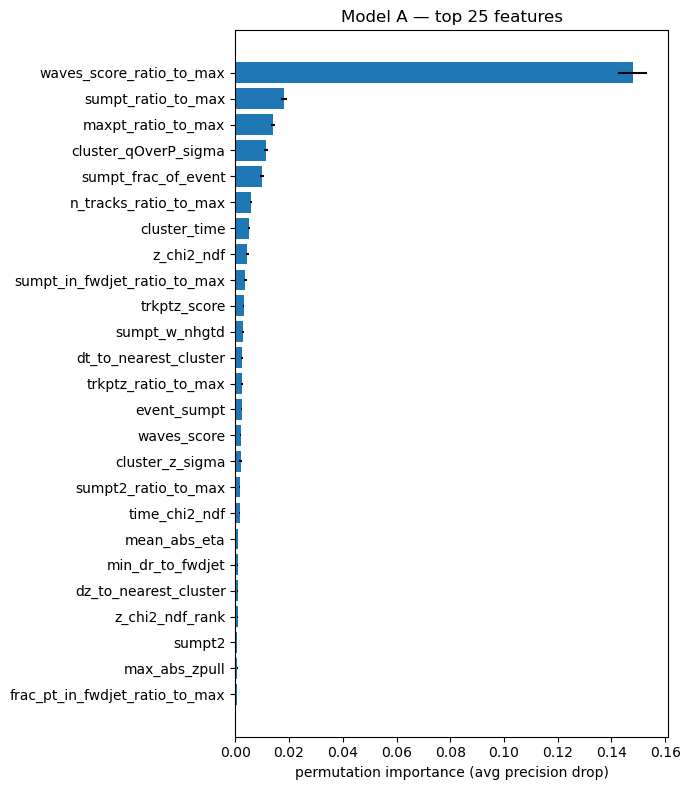

top 25:
   0.14786  waves_score_ratio_to_max
   0.01809  sumpt_ratio_to_max
   0.01403  maxpt_ratio_to_max
   0.01139  cluster_qOverP_sigma
   0.00983  sumpt_frac_of_event
   0.00594  n_tracks_ratio_to_max
   0.00514  cluster_time
   0.00446  z_chi2_ndf
   0.00374  sumpt_in_fwdjet_ratio_to_max
   0.00306  trkptz_score
   0.00293  sumpt_w_nhgtd
   0.00247  dt_to_nearest_cluster
   0.00245  trkptz_ratio_to_max
   0.00232  event_sumpt
   0.00195  waves_score
   0.00192  cluster_z_sigma
   0.00164  sumpt2_ratio_to_max
   0.00157  time_chi2_ndf
   0.00101  mean_abs_eta
   0.00096  min_dr_to_fwdjet
   0.00088  dz_to_nearest_cluster
   0.00082  z_chi2_ndf_rank
   0.00075  sumpt2
   0.00066  max_abs_zpull
   0.00052  frac_pt_in_fwdjet_ratio_to_max

In [9]:
sub = test.sample(min(20000, len(test)), random_state=RANDOM)
imp = permutation_importance(mA, sub[feat], sub["is_best"], n_repeats=5,
                             random_state=RANDOM, scoring="average_precision")
order = np.argsort(imp.importances_mean)[::-1][:25]
plt.figure(figsize=(7, 8))
plt.barh([feat[i] for i in order][::-1], imp.importances_mean[order][::-1],
         xerr=imp.importances_std[order][::-1])
plt.xlabel("permutation importance (avg precision drop)")
plt.title("Model A — top 25 features")
plt.tight_layout(); plt.show()

print("top 25:")
for i in order:
    print(f"  {imp.importances_mean[i]:8.5f}  {feat[i]}")

### 9b. Drop-column ablation — per sample, not pooled

Retrains without a group of features and re-measures the physics metric. Slower than permutation
importance, but it answers what we actually care about: *would we lose anything by not having this?*

**Run it per sample.** A pooled ablation is dominated by whichever sample has the most events and
the least headroom, and that is exactly how a leaking feature stayed hidden here: on VBF (90% →
98% ceiling) dropping `mean_nhgtd_primary` cost **0.0 points**, because `sumpt`/`is_max_trkptz`
already carry that ground. On Z+jets (62% → 92% ceiling) nothing legitimate carries it, and the
same column was worth **~14 points**. One number per sample, or you learn nothing.

The last row is a **leakage sentinel**: it keeps *only* the suspect column plus the two hand-made
scores. If a single feature can move the metric on its own, you want to know before it ends up in
a talk.### 9b. Drop-column ablation — per sample, not pooled

Retrains without a group of features and re-measures the physics metric. Slower than permutation
importance, but it answers what we actually care about: *would we lose anything by not having this?*

**Run it per sample.** A pooled ablation is dominated by whichever sample has the most events and
the least headroom, and that is exactly how a leaking feature stayed hidden here: on VBF (90% →
98% ceiling) dropping `mean_nhgtd_primary` cost **0.0 points**, because `sumpt`/`is_max_trkptz`
already carry that ground. On Z+jets (62% → 92% ceiling) nothing legitimate carries it, and the
same column was worth **~14 points**. One number per sample, or you learn nothing.

The last row is a **leakage sentinel**: it keeps *only* the suspect column plus the two hand-made
scores. If a single feature can move the metric on its own, you want to know before it ends up in
a talk.

In [10]:
ABLATE = {
    "(none - reference)":      [],
    "jet-association block":   [c for c in feat if "fwdjet" in c or "ghost" in c],
    "timing-coherence block":  [c for c in feat if "tpull" in c or "chi2" in c or "timeRes" in c],
    "within-event context":    [c for c in feat if c.endswith(("_ratio_to_max", "_rank"))],
    "hand-made scores":        [c for c in feat if "trkptz" in c or "waves" in c],
}

# COST. This is 5 ablation fits + 1 floor + one per SUSPECT column, where §6 fits
# just 3 -- at COMMON's max_iter it does not finish in a sitting (run 3 was
# interrupted after printing only the header). Ablation is a RELATIVE measure, so
# cap the iterations: the absolute core fractions below will sit slightly under the
# §7 table, and only differences WITHIN this table are meaningful. Raise
# ABLATE_MAX_ITER (or set it to COMMON["max_iter"]) if you want absolutes too.
ABLATE_MAX_ITER = 300
ABLATE_OVER = ({"n_estimators": ABLATE_MAX_ITER} if BACKEND == "xgb"
               else {"max_iter": ABLATE_MAX_ITER})
print(f"(ablation fits capped at max_iter={ABLATE_MAX_ITER}; compare within this "
      f"table only, not against \u00a77)\n")

import time
SIDS = sorted(test["sample_id"].unique())
names = [SAMPLE_NAME.get(s, s) for s in SIDS]

hdr = f"{'dropped':26s} {'nfeat':>5s}" + "".join(f"{n:>10s}" for n in names) + f"{'POOLED':>10s}"
print(hdr); print("-" * len(hdr))

rows = {}
for name, drop in ABLATE.items():
    f = [c for c in feat if c not in set(drop)]
    t0 = time.time()
    m = fit_gbdt(gbdt("clf", **ABLATE_OVER), f, "is_best", train)
    t2 = test.copy(); t2["p"] = proba(m, t2[f])
    per = [select_metric(t2[t2.sample_id == s], "p")[0] for s in SIDS]
    pooled = select_metric(t2, "p")[0]
    rows[name] = per + [pooled]
    print(f"{name:26s} {len(f):5d}" + "".join(f"{v:9.1f}%" for v in per + [pooled])
          + f"   [{time.time()-t0:.0f}s]", flush=True)

# deltas vs the reference row -- this is the number to read
ref = rows["(none - reference)"]
print("\ncost of dropping (negative = the block was helping):")
for name, v in rows.items():
    if name.startswith("(none"):
        continue
    print(f"{name:26s} {'':5s}" + "".join(f"{a-b:+9.1f} " for a, b in zip(v, ref)))

# reference points
print(f"\n{'TRKPTZ baseline':26s} {'':5s}" +
      "".join(f"{select_metric(test[test.sample_id==s], 'trkptz_score')[0]:9.1f}%" for s in SIDS) +
      f"{select_metric(test, 'trkptz_score')[0]:9.1f}%")
print(f"{'oracle ceiling':26s} {'':5s}" +
      "".join(f"{select_metric(test[test.sample_id==s], 'abs_dt', False)[0]:9.1f}%" for s in SIDS) +
      f"{select_metric(test, 'abs_dt', False)[0]:9.1f}%")

# ---- leakage sentinel -------------------------------------------------------
# Train on a SINGLE suspect column (+ the hand-made scores as a floor). If adding
# one feature to that floor moves the metric materially -- especially on the hard
# sample -- treat it as leakage until proven otherwise. Point SUSPECT at anything
# whose provenance you have not personally traced through the Athena source.
SUSPECT = [c for c in ["is_lepton", "n_lepton_tracks", "sumpt_lepton", "dz_to_lepton_z0"]
           if c in feat]
FLOOR = [c for c in feat if "trkptz" in c or "waves" in c]
if SUSPECT:
    print("\nleakage sentinel (hand-made scores + one suspect column at a time):")
    mf = fit_gbdt(gbdt("clf", **ABLATE_OVER), FLOOR, "is_best", train, weights=False)
    tf = test.copy(); tf["p"] = proba(mf, tf[FLOOR])
    base = [select_metric(tf[tf.sample_id == s], "p")[0] for s in SIDS]
    print(f"  {'floor (scores only)':30s}" + "".join(f"{v:9.1f}%" for v in base))
    for c in SUSPECT:
        f = FLOOR + [c]
        m = fit_gbdt(gbdt("clf", **ABLATE_OVER), f, "is_best", train, weights=False)
        t2 = test.copy(); t2["p"] = proba(m, t2[f])
        per = [select_metric(t2[t2.sample_id == s], "p")[0] for s in SIDS]
        print(f"  {'+ ' + c:30s}" + "".join(f"{v:9.1f}%" for v in per) +
              "   delta " + " ".join(f"{a-b:+.1f}" for a, b in zip(per, base)), flush=True)
else:
    print("\n(no SUSPECT columns present in feat -- edit SUSPECT to re-arm the sentinel)")

(ablation fits capped at max_iter=300; compare within this table only, not against §7)

dropped                    nfeat       vbf     zjets     dijet    POOLED
------------------------------------------------------------------------(none - reference)           107     92.8%     65.9%     89.3%     90.1%   [81s]jet-association block         96     92.7%     65.9%     89.2%     90.0%   [92s]timing-coherence block        96     92.7%     65.3%     89.1%     89.9%   [78s]within-event context          75     92.5%     65.5%     88.8%     89.7%   [76s]hand-made scores              98     92.8%     65.7%     89.2%     90.0%   [79s]
cost of dropping (negative = the block was helping):
jet-association block                -0.1      +0.0      -0.1      -0.1 
timing-coherence block               -0.1      -0.6      -0.2      -0.1 
within-event context                 -0.4      -0.4      -0.5      -0.4 
hand-made scores                     -0.0      -0.1      -0.1      -0.0 
TRKPTZ baseline      

## 10. Residual distribution

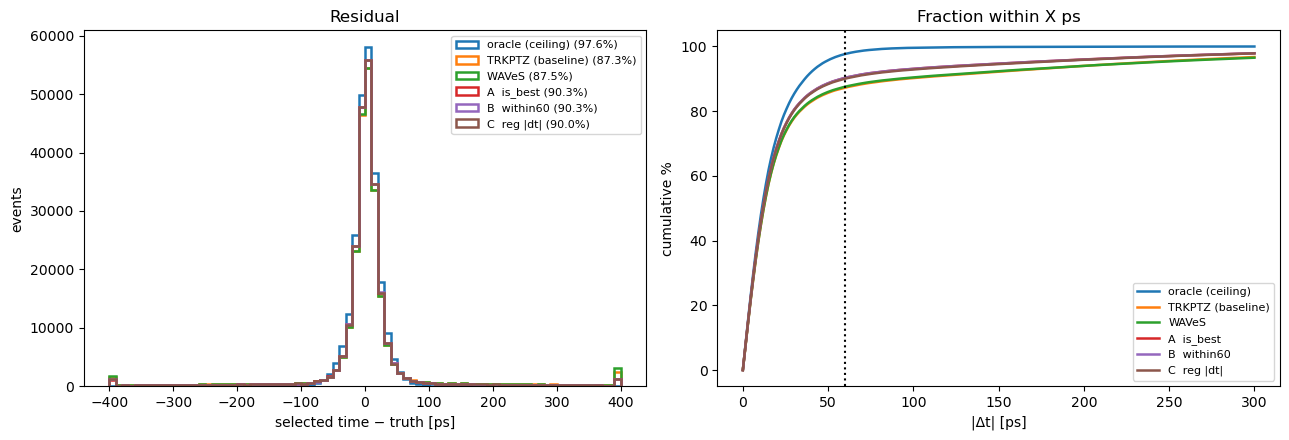

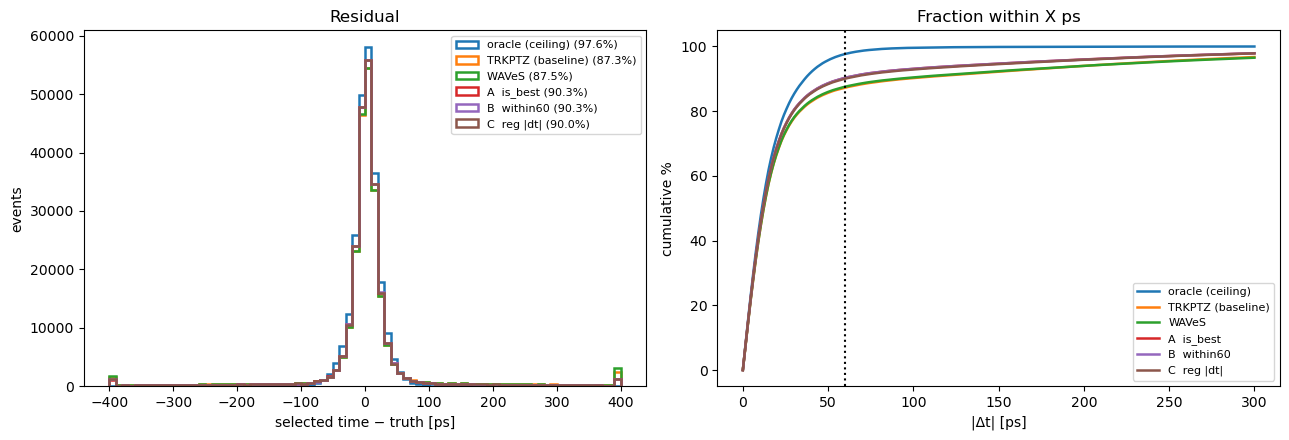

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-400, 400, 81)
for name, col, hib in ROWS:
    s = test[col].fillna(-np.inf if hib else np.inf)
    idx = s.groupby([test[c] for c in EVT], sort=False)
    idx = idx.idxmax() if hib else idx.idxmin()
    sel = test.loc[idx.to_numpy()]
    ax[0].hist(np.clip(sel["delta_t"], bins[0], bins[-1]), bins=bins,
               histtype="step", lw=1.8, label=f"{name} ({(sel['abs_dt']<PASS_PS).mean()*100:.1f}%)")
    x = np.linspace(0, 300, 200)
    ax[1].plot(x, [100*(sel["abs_dt"] < v).mean() for v in x], lw=1.8, label=name)
ax[0].set_xlabel("selected time − truth [ps]"); ax[0].set_ylabel("events")
ax[0].legend(fontsize=8); ax[0].set_title("Residual")
ax[1].axvline(PASS_PS, ls=":", c="k"); ax[1].set_xlabel("|Δt| [ps]")
ax[1].set_ylabel("cumulative %"); ax[1].legend(fontsize=8)
ax[1].set_title("Fraction within X ps")
plt.tight_layout(); plt.show()

## 11. Phase 2 — per-track P(HS), aggregated to a cluster score

The cluster-level model closes only **14% of the gap on Z+jets**, which is where 26 of the
~30 available points sit. This section attacks it from the other side.

**Idea.** Every track carries a truth label (`truth_is_hs`), so the `tracks` tree has ~23M labelled
examples versus 782k events — nearly two orders of magnitude more training signal. Learn
`P(HS | track)`, then score a cluster by `Σ pT·P(HS)`.

That expression is exactly what WAVeS approximates by hand with `pT·pT_jet/ΔR` — WAVeS is guessing
at `P(HS)` using jet proximity as a proxy, which is why it works on VBF (forward jets *are* HS) and
fails on Z+jets (forward jets are pileup). Learning it should remove that topology dependence.

Four engineering points:
- **Memory**: the track tree is far too big to hold at once, so we stream it with `uproot.iterate`
  and only ever keep batch-level aggregates.
- **Per-sample quotas.** ⚠️ The first version of this cell streamed the files in order and
  `break`-ed at `TRACK_TRAIN_MAX`. VBF alone supplies ~12.5M train-fold track rows against a 4M
  cap, so **the track model was trained on 100% VBF tracks** and then applied to Z+jets and dijet —
  precisely the topology mismatch this section exists to remove. Now each sample gets its own
  quota and the per-sample composition is printed, so a repeat is visible rather than silent.
- **Batch-safe aggregation**: a cluster's tracks can straddle a batch boundary, so we accumulate
  only **sums and counts** (which combine across batches) and derive means at the end. Never `mean`
  or `median` per batch.
- **No leakage**: the track model is trained on tracks from **train-fold events only**, reusing the
  same event-level split, so the cluster-level evaluation stays honest.

In [12]:
TRACK_LABEL = "truth_is_hs"
TRACK_FEATURES = ["pt", "eta", "theta", "z0", "d0", "qOverP",
                  "sigma_z0", "sigma_d0", "sigma_qOverP",
                  "time", "timeRes", "time_valid", "quality", "nhgtd_hits",
                  "z0_pull_pv", "t_pull_cluster",
                  "dr_nearest_fwdjet", "pt_nearest_fwdjet", "is_ghost_of_nearest",
                  "is_lepton", "cluster_time", "cluster_delta_z"]
KEY = ["sample_id", "event_num", "cluster_idx"]
# TRACK_FEATURES is an explicit allowlist, so truth columns cannot sneak in the way
# they can on the cluster side -- but assert it anyway, including the pre-rename
# alias (the tracks tree carries nhgtd_primary / truth_nhgtd_primary).
_bad = [f for f in TRACK_FEATURES if f.startswith("truth_") or f in set(TRUTH_ALIASES)]
assert not _bad, f"TRUTH IN TRACK FEATURES: {_bad}"

READ = sorted(set(TRACK_FEATURES + KEY + [TRACK_LABEL]))
TRACK_TRAIN_MAX = 4_000_000     # total across samples; raise if you have headroom
STEP = "300 MB"

# Stream each sample SEPARATELY with its own quota. The previous version iterated
# a single concatenated path list and broke at the global cap, which -- because vbf
# is listed first and carries ~12.5M train-fold track rows on its own -- trained the
# P(HS) model on vbf tracks exclusively. Since the whole point is to remove the
# topology dependence that sinks WAVeS on Z+jets, that quietly defeated the section.
SAMPLE_PATHS = {name: f"{p}:tracks" for name, p in FILES.items()}
QUOTA = TRACK_TRAIN_MAX // max(1, len(SAMPLE_PATHS))
fold  = ev.set_index(EVT)["fold"]                    # same split as the cluster model

def batch_fold(b):
    return fold.reindex(pd.MultiIndex.from_arrays(
        [b["sample_id"], b["event_num"]])).to_numpy()

# ---- pass 1: per-sample training subsample, TRAIN-fold events only ---------
chunks = []
print(f"per-sample quota: {QUOTA:,} rows")
for name, path in SAMPLE_PATHS.items():
    n = 0
    for b in uproot.iterate(path, READ, library="pd", step_size=STEP):
        bf = batch_fold(b)
        keep = bf < 0.7
        # carry `fold` so the track model can use the same event-disjoint
        # early-stopping slice as every other model (see split_tv in §6)
        b = b[keep].assign(fold=bf[keep])
        if len(b) == 0:
            continue
        if n + len(b) > QUOTA:
            b = b.sample(max(0, QUOTA - n), random_state=RANDOM)
        if len(b):
            chunks.append(b); n += len(b)
        if n >= QUOTA:
            break
    got = "quota met" if n >= QUOTA else "ALL available (under quota)"
    print(f"  {name:6s} {n:>9,} rows   {got}")
trk = pd.concat(chunks, ignore_index=True); del chunks

print(f"\ntrack training rows: {len(trk):,}   P(HS) prior = {trk[TRACK_LABEL].mean():.3f}")
print("composition and per-sample prior (both should be non-degenerate):")
comp = trk.groupby("sample_id").agg(rows=(TRACK_LABEL, "size"), prior=(TRACK_LABEL, "mean"))
comp["frac"] = comp["rows"] / len(trk)
print(comp)
assert len(comp) == len(SAMPLE_PATHS), \
    f"track model sees only {len(comp)} of {len(SAMPLE_PATHS)} samples -- quota logic broke"

mT = fit_gbdt(gbdt("clf"), TRACK_FEATURES, TRACK_LABEL, trk, weights=False)
print(f"\nbackend: {BACKEND}   trees used: {n_trees(mT)}")

# Flat path list for the aggregation pass in 11b (which must read EVERY sample,
# unlike the quota-limited training pass above).
ALL_TRACK_PATHS = list(SAMPLE_PATHS.values())

# Staleness guard. 11b/11c consume `agg`, which is derived from THIS model; if the
# model is refit and 11b is not re-run, 11c silently reports the old model's numbers
# from a stale `agg` still in the kernel. That already happened once (run 3: cell 24
# re-executed at In[27] while the aggregation sat at In[24], so the "fixed" Phase-2
# numbers were still the vbf-only model's). Bump on every fit; 11b records it and
# 11c asserts they match.
MT_FIT_ID = globals().get("MT_FIT_ID", 0) + 1
print(f"MT_FIT_ID = {MT_FIT_ID}  (re-run 11b before 11c)")

per-sample quota: 1,333,333 rows  vbf    1,333,333 rows   quota met  zjets  1,226,314 rows   ALL available (under quota)  dijet  1,333,333 rows   quota met

track training rows: 3,892,980   P(HS) prior = 0.287
composition and per-sample prior (both should be non-degenerate):
              rows     prior      frac
sample_id                             
0.0        1333333  0.314821  0.342497
1.0        1226314  0.206923  0.315006
2.0        1333333  0.332753  0.342497
backend: xgb   trees used: 1997
MT_FIT_ID = 1  (re-run 11b before 11c)

### 11b. Stream over all tracks and aggregate per cluster

Only sum-like accumulators, so batch boundaries splitting a cluster are harmless.

In [13]:
parts = []
for b in uproot.iterate(ALL_TRACK_PATHS, READ, library="pd", step_size=STEP):
    p = proba(mT, b[TRACK_FEATURES])
    b = b.assign(_p=p, _ptp=b["pt"] * p, _hi=(p > 0.5).astype(np.int8))
    parts.append(b.groupby(KEY, sort=False)
                  .agg(sum_ptp=("_ptp", "sum"), sum_p=("_p", "sum"),
                       max_p=("_p", "max"), n_hi=("_hi", "sum"),
                       sum_pt=("pt", "sum"), n=("_p", "size")))
agg = pd.concat(parts).groupby(level=[0, 1, 2]).agg(
    sum_ptp=("sum_ptp", "sum"), sum_p=("sum_p", "sum"), max_p=("max_p", "max"),
    n_hi=("n_hi", "sum"), sum_pt=("sum_pt", "sum"), n=("n", "sum")).reset_index()
del parts

# derived (safe: built from combinable sums/counts, not per-batch means)
agg["phs_sum_ptp"]  = agg["sum_ptp"]                       # the WAVeS analogue
agg["phs_mean"]     = agg["sum_p"] / agg["n"]
agg["phs_ptw_mean"] = agg["sum_ptp"] / agg["sum_pt"].replace(0, np.nan)
agg["phs_max"]      = agg["max_p"]
agg["phs_n_hi"]     = agg["n_hi"]
PHS = ["phs_sum_ptp", "phs_mean", "phs_ptw_mean", "phs_max", "phs_n_hi"]
AGG_FIT_ID = MT_FIT_ID          # stamp: which track model produced this agg
print(f"aggregated {len(agg):,} clusters   (from MT_FIT_ID={AGG_FIT_ID})")
print(agg[PHS].describe().T[["mean", "50%", "max"]])

aggregated 4,411,382 clusters   (from MT_FIT_ID=1)                  mean       50%         max
phs_sum_ptp   6.261366  0.515817  259.777313
phs_mean      0.227278  0.128113    0.999605
phs_ptw_mean  0.260630  0.132806    0.999605
phs_max       0.370035  0.231490    0.999605
phs_n_hi      1.385996  0.000000   44.000000

### 11c. Does it select better?

Two questions: is `Σ pT·P(HS)` a good selector **on its own** (vs TRKPTZ and the Phase-1 model),
and does adding the P(HS) aggregates as **features** improve the cluster model?

In [14]:
assert globals().get("AGG_FIT_ID") == MT_FIT_ID, (
    f"STALE agg: built from MT_FIT_ID={globals().get('AGG_FIT_ID')} but the current "
    f"track model is MT_FIT_ID={MT_FIT_ID}. Re-run 11b."
)

test2 = test.merge(agg[KEY + PHS], on=KEY, how="left")
gb2   = test2.groupby(EVT, sort=False)
for c in PHS:
    mx = gb2[c].transform("max")
    test2[f"{c}_ratio_to_max"] = np.where(np.abs(mx) > 0, test2[c] / mx, np.nan)
train2 = train.merge(agg[KEY + PHS], on=KEY, how="left")
gb3    = train2.groupby(EVT, sort=False)
for c in PHS:
    mx = gb3[c].transform("max")
    train2[f"{c}_ratio_to_max"] = np.where(np.abs(mx) > 0, train2[c] / mx, np.nan)

# Per sample, not just pooled: vbf is 79% of the test set and is near-saturated,
# so a pooled row is dominated by the sample with nothing left to win. Everything
# interesting about P(HS) is whether it beats TRKPTZ on ZJETS specifically.
STANDALONE = [("TRKPTZ", "trkptz_score"), ("WAVeS", "waves_score"),
              ("Phase-1 model B", "scoreB"),
              ("P(HS): sum pT*P [WAVeS analogue]", "phs_sum_ptp"),
              ("P(HS): pT-weighted mean", "phs_ptw_mean"),
              ("P(HS): max", "phs_max")]
S_IDS = sorted(test2["sample_id"].unique())
S_NAMES = [SAMPLE_NAME.get(s, s) for s in S_IDS]
print("=== standalone selectors (test) ===")
print(f"  {'selector':34s}" + "".join(f"{n:>10s}" for n in S_NAMES) + f"{'POOLED':>10s}")
print("  " + "-" * (34 + 10 * (len(S_IDS) + 1)))
for nm, col in STANDALONE:
    per = [select_metric(test2[test2.sample_id == s], col)[0] for s in S_IDS]
    print(f"  {nm:34s}" + "".join(f"{v:9.1f}%" for v in per)
          + f"{select_metric(test2, col)[0]:9.1f}%")
orc = [select_metric(test2[test2.sample_id == s], "abs_dt", False)[0] for s in S_IDS]
print(f"  {'oracle (ceiling)':34s}" + "".join(f"{v:9.1f}%" for v in orc)
      + f"{select_metric(test2, 'abs_dt', False)[0]:9.1f}%")

print("\n=== cluster model WITH P(HS) features ===")
featP = feat + PHS + [f"{c}_ratio_to_max" for c in PHS]
mP = fit_gbdt(gbdt("clf"), featP, "is_best", train2)
test2["scoreP"] = proba(mP, test2[featP])
for lbl, frame, sub in ([("ALL", test2, None)] +
                        [(SAMPLE_NAME.get(s, s), test2, s) for s in sorted(test2.sample_id.unique())]):
    f = frame if sub is None else frame[frame.sample_id == sub]
    b  = select_metric(f, "trkptz_score")[0]
    p1 = select_metric(f, "scoreB")[0]
    p2 = select_metric(f, "scoreP")[0]
    o  = select_metric(f, "abs_dt", False)[0]
    print(f"  {lbl:8s} TRKPTZ {b:5.1f}%  ph1 {p1:5.1f}%  ph1+P(HS) {p2:5.1f}%  "
          f"oracle {o:5.1f}%   (+{p2-p1:.1f} from P(HS))")

=== standalone selectors (test) ===
  selector                                 vbf     zjets     dijet    POOLED
  --------------------------------------------------------------------------  TRKPTZ                                 90.1%     62.1%     87.0%     87.3%  WAVeS                                  90.7%     60.2%     86.3%     87.5%  Phase-1 model B                        93.0%     66.5%     89.5%     90.3%  P(HS): sum pT*P [WAVeS analogue]       91.7%     64.6%     88.4%     88.9%  P(HS): pT-weighted mean                77.4%     47.9%     71.4%     74.1%  P(HS): max                             87.7%     58.8%     83.7%     84.7%  oracle (ceiling)                       98.2%     92.2%     97.8%     97.6%

=== cluster model WITH P(HS) features ===  ALL      TRKPTZ  87.3%  ph1  90.3%  ph1+P(HS)  90.5%  oracle  97.6%   (+0.2 from P(HS))  vbf      TRKPTZ  90.1%  ph1  93.0%  ph1+P(HS)  93.1%  oracle  98.2%   (+0.1 from P(HS))
  zjets    TRKPTZ  62.1%  ph1  66.5%  ph1+P(HS)  67.2%  o

## Next steps

**Decision gate:** does any of A/B/C beat TRKPTZ on the §7 table, and does the §8 matrix hold up
off-diagonal? If yes → Phase 2. If no, the tabular features are not carrying the signal and the
per-track route below is the better bet regardless.

1. **Per-track P(HS) model** (highest value). The exporter's `tracks` tree has ~30 rows/event with
   `truth_is_hs` — millions of labeled examples instead of ~67k events. Train `P(HS|track)`, then
   score clusters as `Σ pT·P(HS)`. That is the *learned* form of exactly what WAVeS hard-codes as
   `pT_jet/ΔR`, which is why WAVeS is topology-dependent and this should not be.
2. **Deep Sets over clusters** — permutation-invariant, scores each cluster conditioned on its
   competitors. The principled version of the §4 hand-built context features.
3. **Abstain output** — the ~13% of events with no good cluster are currently unwinnable noise.
   A confidence/margin cut gives the "don't trust this vertex time" flag downstream RpT wants.
4. **Deployment**: inference runs inside `TTreeProcessorMT` over millions of events (~µs/event,
   thread-safe). GBDT or a small MLP via ONNX Runtime is fine; note TMVA is deliberately excluded
   from this build (`CMakeLists.txt`), so ONNX is the path.

## 12. Formulation D — true listwise ranking

Everything so far scores each cluster **independently** and takes an argmax within the event
afterwards. The loss never sees that clusters compete. The `_ratio_to_max`/`_rank` context
features exist purely to smuggle that competition into a pointwise model, because sklearn has
no listwise objective.

`LGBMRanker`/`XGBRanker` optimise the ordering *within a group* directly, where the group is the
event. This is the formulation the whole notebook has been approximating.

**Graded relevance, not binary.** Relevance is `2` for the truth-closest cluster, `1` for any
other cluster inside the 60 ps window, `0` otherwise. This tells the loss that picking a
non-best cluster that still lands in the window is a far better mistake than one that does not —
which is exactly what the physics metric measures. Binary `is_best` throws that distinction away.

**Honest early stopping**: the validation slice is carved out of *train* (`0.60 ≤ fold < 0.70`,
the same `split_tv` every other model uses), never out of test.

> **What to expect.** §9b showed that dropping the within-event context features costs only 0.3
> points — and those features exist specifically to fake this loss. So either a real ranking
> objective does meaningfully better on Z+jets, or we have confirmed that the pointwise framing
> was never the limitation and the remaining ~25 points simply are not in per-cluster features.
> Both answers are worth having; the second is what would justify moving to a track-level set
> model.

In [15]:
assert HAVE_LGB or HAVE_XGB, "no ranker available -- switch to the Python (vtx) kernel"

# Rankers need rows grouped contiguously by event.
def as_groups(frame):
    f = frame.sort_values(EVT, kind="mergesort")
    return f, f.groupby(EVT, sort=False).size().to_numpy()

def relevance(f):
    return np.where(f["is_best"] == 1, 2, np.where(f["within60"] == 1, 1, 0))

TRN_R, VAL_R = split_tv(train)
TR, TRG = as_groups(TRN_R)
VA, VAG = as_groups(VAL_R)
TE, TEG = as_groups(test)
print(f"rank train {len(TRG):,} events / {len(TR):,} rows | "
      f"val {len(VAG):,} events | test {len(TEG):,} events")

RANK_ROUNDS = 2000

if HAVE_LGB:
    mL = lgb.LGBMRanker(objective="lambdarank", n_estimators=RANK_ROUNDS,
                        learning_rate=0.06, num_leaves=31, min_child_samples=50,
                        reg_lambda=1.0, subsample=0.8, subsample_freq=1,
                        colsample_bytree=0.8, label_gain=[0, 1, 3], eval_at=[1],
                        random_state=RANDOM, n_jobs=-1, verbose=-1)
    mL.fit(TR[feat], relevance(TR), group=TRG,
           eval_set=[(VA[feat], relevance(VA))], eval_group=[VAG],
           callbacks=[lgb.early_stopping(50, verbose=False)])
    TE["scoreL"] = mL.predict(TE[feat], num_iteration=mL.best_iteration_)
    print(f"LGBMRanker  best iteration: {mL.best_iteration_}")

if HAVE_XGB:
    # XGBRanker takes qid rather than group sizes; rows must already be sorted.
    qid = lambda f: f.groupby(EVT, sort=False).ngroup().to_numpy()
    mX = xgb.XGBRanker(objective="rank:ndcg", eval_metric=["ndcg@1"],
                       n_estimators=RANK_ROUNDS, learning_rate=0.06,
                       max_leaves=31, max_depth=0, grow_policy="lossguide",
                       min_child_weight=5, reg_lambda=1.0,
                       subsample=0.8, colsample_bytree=0.8,
                       tree_method="hist", n_jobs=-1, random_state=RANDOM,
                       early_stopping_rounds=50)
    mX.fit(TR[feat], relevance(TR), qid=qid(TR),
           eval_set=[(VA[feat], relevance(VA))], eval_qid=[qid(VA)], verbose=False)
    TE["scoreX"] = mX.predict(TE[feat])
    print(f"XGBRanker   best iteration: {mX.best_iteration}")

# ------------------------------- comparison ---------------------------------
ROWS_D = [("TRKPTZ (baseline)", "trkptz_score"), ("WAVeS", "waves_score"),
          ("B  within60 (pointwise)", "scoreB")]
if HAVE_LGB: ROWS_D.append(("D  LGBMRanker lambdarank", "scoreL"))
if HAVE_XGB: ROWS_D.append(("D  XGBRanker rank:ndcg", "scoreX"))

D_IDS = sorted(TE["sample_id"].unique())
print(f"\n{'selector':28s}" + "".join(f"{SAMPLE_NAME.get(s,s):>10s}" for s in D_IDS)
      + f"{'POOLED':>10s}")
print("-" * (28 + 10 * (len(D_IDS) + 1)))
base = {s: select_metric(TE[TE.sample_id == s], "trkptz_score")[0] for s in D_IDS}
for nm, col in ROWS_D:
    per = [select_metric(TE[TE.sample_id == s], col)[0] for s in D_IDS]
    print(f"{nm:28s}" + "".join(f"{v:9.1f}%" for v in per)
          + f"{select_metric(TE, col)[0]:9.1f}%")
orc = [select_metric(TE[TE.sample_id == s], "abs_dt", False)[0] for s in D_IDS]
print(f"{'oracle (ceiling)':28s}" + "".join(f"{v:9.1f}%" for v in orc)
      + f"{select_metric(TE, 'abs_dt', False)[0]:9.1f}%")

print("\nvs TRKPTZ:")
for nm, col in ROWS_D[2:]:
    d = [select_metric(TE[TE.sample_id == s], col)[0] - base[s] for s in D_IDS]
    print(f"{nm:28s}" + "".join(f"{v:+9.1f} " for v in d))

rank train 468,793 events / 2,644,414 rows | val 77,845 events | test 235,142 eventsLGBMRanker  best iteration: 420XGBRanker   best iteration: 460

selector                           vbf     zjets     dijet    POOLED
--------------------------------------------------------------------TRKPTZ (baseline)                90.1%     62.1%     87.0%     87.3%WAVeS                            90.7%     60.2%     86.3%     87.5%B  within60 (pointwise)          93.0%     66.5%     89.5%     90.3%D  LGBMRanker lambdarank         93.2%     66.9%     89.8%     90.5%D  XGBRanker rank:ndcg           93.2%     66.9%     89.8%     90.5%oracle (ceiling)                 98.2%     92.2%     97.8%     97.6%

vs TRKPTZ:B  within60 (pointwise)          +2.9      +4.4      +2.6 D  LGBMRanker lambdarank         +3.2      +4.8      +2.9 D  XGBRanker rank:ndcg           +3.1      +4.8      +2.8 

autopsy: sample=zjets  score='scoreL'  20,258 events / 114,572 clusters
recoverable 18,683   hit 13,547 (72.5%)   MISS 5,136 (27.5%)

[A] oracle restricted to the model's top-k:
      top-1    66.9%
      top-2    81.2%
      top-3    87.4%
      top-5    91.7%
      top-10   92.2%
      all     92.2%   <- ceiling

[B] rank of the best acceptable cluster, on MISS events:
      rank 2        2,904   56.5%
      rank 3        1,263   24.6%
      rank 4-5        863   16.8%
      rank 6-10       106    2.1%
      rank >10          0    0.0%      median rank 2 of 6 clusters/event

[C] score margin (chosen - target), in units of the event's score spread:
      median 0.64   p90 1.65   within 0.25 sigma: 21.6%

[D] median (target - chosen) on MISS events, in feature sigmas:
       -2.621  is_max_sumpt  (score-like: circular, ignore)
       -2.621  is_max_trkptz  (score-like: circular, ignore)
       -1.702  waves_score_ratio_to_max  (score-like: circular, ignore)
       -1.612  trkptz_ratio_

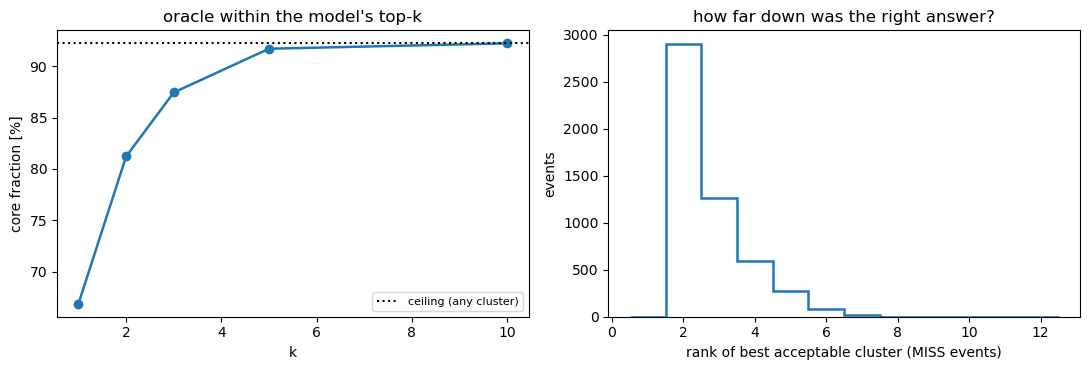

In [17]:
# ============ §13. Failure autopsy — is the remaining gap reducible? ==========
AUTOPSY_SAMPLE = "zjets"          # None (or a name not present) pools everything
K_RERANK       = 3                # candidate depth for the stage-2 test in [E]
RR_TRAIN_FRAC  = 0.70             # share of test events used to fit the re-ranker

FRAME = TE if ("TE" in globals() and "scoreL" in TE.columns) else test
SCORE = "scoreL" if "scoreL" in FRAME.columns else "scoreB"
_rev  = {v: k for k, v in SAMPLE_NAME.items()}
_sid  = _rev.get(AUTOPSY_SAMPLE)
_has  = _sid is not None and _sid in set(FRAME["sample_id"])
F = (FRAME[FRAME.sample_id == _sid] if _has else FRAME).copy()
print(f"autopsy: sample={AUTOPSY_SAMPLE if _has else 'ALL'}  score='{SCORE}'  "
      f"{F.groupby(EVT).ngroups:,} events / {len(F):,} clusters")

g = F.groupby(EVT, sort=False)
F["_rank"]  = g[SCORE].rank(ascending=False, method="first")
F["_nclus"] = g[SCORE].transform("size")

ev_rec = g["within60"].max()                       # 1 if ANY cluster is acceptable
chosen = F.loc[g[SCORE].idxmax()].set_index(EVT)
rec    = F[F.within60 == 1]
# `target` = the acceptable cluster the model ranked HIGHEST: the easiest right
# answer available to it, i.e. the most favourable counterfactual.
target = rec.loc[rec.groupby(EVT, sort=False)[SCORE].idxmax()].set_index(EVT)

REC  = ev_rec[ev_rec == 1].index
ch, tg = chosen.loc[REC], target.loc[REC]
miss = (ch["within60"] == 0).to_numpy()
M, H = ch.index[miss], ch.index[~miss]
print(f"recoverable {len(REC):,}   hit {(~miss).sum():,} ({100*(~miss).mean():.1f}%)"
      f"   MISS {miss.sum():,} ({100*miss.mean():.1f}%)\n")

print("[A] oracle restricted to the model's top-k:")
topk = {}
for k in (1, 2, 3, 5, 10):
    topk[k] = 100 * F[F._rank <= k].groupby(EVT)["within60"].max().mean()
    print(f"      top-{k:<3d} {topk[k]:5.1f}%")
print(f"      all    {100*ev_rec.mean():5.1f}%   <- ceiling\n")

tr = tg.loc[M, "_rank"]
print("[B] rank of the best acceptable cluster, on MISS events:")
for lo, hi, lab in ((2,2,"2"), (3,3,"3"), (4,5,"4-5"), (6,10,"6-10"), (11,10**9,">10")):
    n = int(((tr >= lo) & (tr <= hi)).sum())
    print(f"      rank {lab:<6s} {n:7,}  {100*n/max(1,len(tr)):5.1f}%")
print(f"      median rank {tr.median():.0f} of {ch.loc[M,'_nclus'].median():.0f} clusters/event\n")

sd_by_ev = F.groupby(EVT, sort=False)[SCORE].std()
marg = (ch.loc[M, SCORE] - tg.loc[M, SCORE]) / sd_by_ev.loc[M].replace(0, np.nan)
print("[C] score margin (chosen - target), in units of the event's score spread:")
print(f"      median {marg.median():.2f}   p90 {marg.quantile(0.90):.2f}   "
      f"within 0.25 sigma: {100*(marg < 0.25).mean():.1f}%\n")

# CAVEAT: `chosen` is by definition the score argmax, so every feature correlated
# with the score is guaranteed negative here. That part is circular and carries no
# information. Read only the NON-score-like rows: geometry, timing, jet association.
num = [c for c in feat if pd.api.types.is_numeric_dtype(F[c])]
D  = tg.loc[M, num].to_numpy(dtype=float) - ch.loc[M, num].to_numpy(dtype=float)
sd = F[num].std().replace(0, np.nan).to_numpy(dtype=float)
with np.errstate(invalid="ignore", divide="ignore"):
    Z = np.nanmedian(D / sd, axis=0)
SCORE_LIKE = ("trkptz", "waves", "sumpt", "maxpt", "is_max", "_rank", "ratio_to_max")
print("[D] median (target - chosen) on MISS events, in feature sigmas:")
for i in sorted(range(len(num)), key=lambda i: -abs(np.nan_to_num(Z[i])))[:12]:
    tag = "  (score-like: circular, ignore)" if any(s in num[i] for s in SCORE_LIKE) else ""
    print(f"      {Z[i]:+7.3f}  {num[i]}{tag}")

# [E] NOT a paired target-vs-chosen classifier: `chosen` is the score argmax, so
# score-correlated features separate the pair perfectly by construction and any
# such AUC is an artifact of the selection, not evidence of information.
# Honest version: within the model's top-K, can a FRESH classifier with no access
# to the first-stage score reorder them better? Disjoint test events both sides.
cand = F[F._rank <= K_RERANK].copy()
_ev  = cand[EVT].drop_duplicates().reset_index(drop=True)
_ev["_half"] = np.random.default_rng(RANDOM).random(len(_ev)) < RR_TRAIN_FRAC
cand = cand.merge(_ev, on=EVT, how="left")
A, B = cand[cand._half], cand[~cand._half]
RR_FEAT = [c for c in feat if c != SCORE and not any(s in c for s in ("trkptz", "waves"))]
over = ({"n_estimators": 400, "early_stopping_rounds": None}
        if BACKEND == "xgb" else {"max_iter": 400})
print(f"\n[E] stage-2 re-ranking within top-{K_RERANK}"
      f"   (fit on {A.groupby(EVT).ngroups:,} events, eval on {B.groupby(EVT).ngroups:,};"
      f" {len(RR_FEAT)} features, first-stage and hand-made scores excluded)")
if A.groupby(EVT).ngroups < 2000:
    print("    !! few events -- treat the numbers below as indicative only")
m2 = gbdt("clf", **over).fit(A[RR_FEAT], A["within60"])
B = B.copy(); B["_p2"] = proba(m2, B[RR_FEAT])
gb  = B.groupby(EVT, sort=False)
s1  = B.loc[gb["_rank"].idxmin(), "within60"].mean()
s2  = B.loc[gb["_p2"].idxmax(),  "within60"].mean()
orc = gb["within60"].max().mean()
print(f"      stage-1 (current)      {100*s1:5.1f}%")
print(f"      stage-2 re-ranked      {100*s2:5.1f}%   ({100*(s2-s1):+.1f})")
print(f"      oracle within top-{K_RERANK}    {100*orc:5.1f}%   <- what re-ranking could reach")
print("      " + ("=> no recoverable signal: IRREDUCIBLE with these features"
                  if s2 - s1 < 0.005 else
                  "=> real signal available; re-ranking is worth building"))

cand_cols = [c for c in ("n_tracks", "sumpt", "_nclus", "n_valid_time", "event_sumpt",
                         "min_dr_to_fwdjet", "sumpt_frac_of_event", "cluster_time_sigma",
                         "delta_z_resunits") if c in ch.columns]
if cand_cols:
    cmp = pd.DataFrame({"HIT (median)": ch.loc[H, cand_cols].median(),
                        "MISS (median)": ch.loc[M, cand_cols].median()})
    cmp["ratio"] = cmp["MISS (median)"] / cmp["HIT (median)"].replace(0, np.nan)
    print("\n[F] chosen-cluster properties, hit vs miss:")
    print(cmp.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ks = sorted(topk)
ax[0].plot(ks, [topk[k] for k in ks], "o-", lw=1.8)
ax[0].axhline(100 * ev_rec.mean(), ls=":", c="k", label="ceiling (any cluster)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("core fraction [%]")
ax[0].set_title("oracle within the model's top-k"); ax[0].legend(fontsize=8)
ax[1].hist(np.clip(tr, 0, 12), bins=np.arange(0.5, 13.5), histtype="step", lw=1.8)
ax[1].set_xlabel("rank of best acceptable cluster (MISS events)")
ax[1].set_ylabel("events"); ax[1].set_title("how far down was the right answer?")
plt.tight_layout(); plt.show()

In [18]:
# ====== §14. Ceiling of ANY per-track method — before building a set model =====
from sklearn.metrics import roc_auc_score

AUC_CAP = 3_000_000        # test-fold tracks retained for the AUC estimate
parts, auc_rows = [], []
seen = 0
for b in uproot.iterate(ALL_TRACK_PATHS, READ, library="pd", step_size=STEP):
    p  = proba(mT, b[TRACK_FEATURES])
    y  = b[TRACK_LABEL].to_numpy()
    bf = batch_fold(b)
    te = bf >= 0.7                                   # honest: test-fold only
    if te.any() and seen < AUC_CAP:
        k = min(int(te.sum()), AUC_CAP - seen)
        idx = np.flatnonzero(te)[:k]
        auc_rows.append(pd.DataFrame({"sample_id": b["sample_id"].to_numpy()[idx],
                                      "p": p[idx], "y": y[idx]}))
        seen += k
    bb = b.assign(_hs=b["pt"].to_numpy() * y, _p=b["pt"].to_numpy() * p)
    parts.append(bb.groupby(KEY, sort=False).agg(
        pt_hs=("_hs", "sum"), pt_p=("_p", "sum"),
        pt=("pt", "sum"), n_hs=(TRACK_LABEL, "sum"), n=("pt", "size")))

agg2 = (pd.concat(parts).groupby(level=[0, 1, 2])
        .agg(pt_hs=("pt_hs", "sum"), pt_p=("pt_p", "sum"), pt=("pt", "sum"),
             n_hs=("n_hs", "sum"), n=("n", "sum")).reset_index())
del parts
agg2["trk_oracle"]  = agg2["pt_hs"]                              # perfect tagger
agg2["trk_learned"] = agg2["pt_p"]                               # current P(HS)
agg2["hs_ptfrac"]   = agg2["pt_hs"] / agg2["pt"].replace(0, np.nan)
print(f"aggregated {len(agg2):,} clusters")

A = pd.concat(auc_rows, ignore_index=True); del auc_rows
print(f"\nper-track P(HS) discrimination (test-fold tracks, n={len(A):,}):")
print(f"  {'sample':10s} {'AUC':>8s} {'prior':>8s} {'n':>12s}")
for s, sub in A.groupby("sample_id"):
    if sub["y"].nunique() < 2: continue
    print(f"  {SAMPLE_NAME.get(s,s):10s} {roc_auc_score(sub['y'], sub['p']):8.3f}"
          f" {sub['y'].mean():8.3f} {len(sub):12,}")
print(f"  {'ALL':10s} {roc_auc_score(A['y'], A['p']):8.3f} {A['y'].mean():8.3f} {len(A):12,}")

T = test.merge(agg2[KEY + ["trk_oracle", "trk_learned", "hs_ptfrac"]], on=KEY, how="left")
SIDS = sorted(T["sample_id"].unique())
ROWS = [("TRKPTZ (baseline)",              "trkptz_score", True),
        ("WAVeS",                          "waves_score",  True),
        ("cluster model B",                "scoreB",       True),
        ("Sum pT*P(HS)  [learned]",        "trk_learned",  True),
        ("Sum pT*truth  [TRACK ORACLE]",   "trk_oracle",   True),
        ("HS pT fraction [truth]",         "hs_ptfrac",    True),
        ("cluster oracle (ceiling)",       "abs_dt",       False)]
print(f"\n{'selector':32s}" + "".join(f"{SAMPLE_NAME.get(s,s):>10s}" for s in SIDS)
      + f"{'POOLED':>10s}")
print("-" * (32 + 10 * (len(SIDS) + 1)))
res = {}
for nm, col, hib in ROWS:
    per = [select_metric(T[T.sample_id == s], col, hib)[0] for s in SIDS]
    res[nm] = per
    print(f"{nm:32s}" + "".join(f"{v:9.1f}%" for v in per)
          + f"{select_metric(T, col, hib)[0]:9.1f}%")

print("\nhow much of the gap does a PERFECT per-track tagger reach?")
print(f"  {'sample':10s} {'TRKPTZ':>8s} {'learned':>9s} {'trk-orac':>9s} "
      f"{'ceiling':>9s} {'orac closes':>12s} {'learn closes':>13s}")
for i, s in enumerate(SIDS):
    b   = res["TRKPTZ (baseline)"][i]
    lr  = res["Sum pT*P(HS)  [learned]"][i]
    orc = res["Sum pT*truth  [TRACK ORACLE]"][i]
    ceil= res["cluster oracle (ceiling)"][i]
    den = max(1e-9, ceil - b)
    print(f"  {SAMPLE_NAME.get(s,s):10s} {b:7.1f}% {lr:8.1f}% {orc:8.1f}% {ceil:8.1f}%"
          f" {100*(orc-b)/den:11.0f}% {100*(lr-b)/den:12.0f}%")

aggregated 4,411,382 clusters

per-track P(HS) discrimination (test-fold tracks, n=3,000,000):
  sample          AUC    prior            n  vbf           0.918    0.315    3,000,000  ALL           0.918    0.315    3,000,000
selector                               vbf     zjets     dijet    POOLED
------------------------------------------------------------------------TRKPTZ (baseline)                    90.1%     62.1%     87.0%     87.3%WAVeS                                90.7%     60.2%     86.3%     87.5%cluster model B                      93.0%     66.5%     89.5%     90.3%Sum pT*P(HS)  [learned]              91.7%     64.6%     88.4%     88.9%Sum pT*truth  [TRACK ORACLE]         94.8%     80.2%     93.8%     93.4%HS pT fraction [truth]               66.7%     59.1%     61.9%     65.5%cluster oracle (ceiling)             98.2%     92.2%     97.8%     97.6%

how much of the gap does a PERFECT per-track tagger reach?
  sample       TRKPTZ   learned  trk-orac   ceiling  orac closes 

In [19]:
from sklearn.metrics import roc_auc_score
PER = 1_000_000
buf = {}
for b in uproot.iterate(ALL_TRACK_PATHS, READ, library="pd", step_size=STEP):
    te = batch_fold(b) >= 0.7
    if not te.any(): continue
    sub = b[te]
    for s, grp in sub.groupby("sample_id"):
        have = sum(len(x) for x in buf.get(s, []))
        if have >= PER: continue
        g = grp.iloc[:PER - have]
        buf.setdefault(s, []).append(pd.DataFrame(
            {"p": proba(mT, g[TRACK_FEATURES]), "y": g[TRACK_LABEL].to_numpy()}))
    if all(sum(len(x) for x in v) >= PER for v in buf.values()) and len(buf) >= len(SAMPLE_PATHS):
        break
print(f"  {'sample':10s} {'AUC':>8s} {'prior':>8s} {'n':>12s}")
for s, chunks in buf.items():
    d = pd.concat(chunks, ignore_index=True)
    print(f"  {SAMPLE_NAME.get(s,s):10s} {roc_auc_score(d.y, d.p):8.3f} {d.y.mean():8.3f} {len(d):12,}")

  sample          AUC    prior            n  vbf           0.918    0.316    1,000,000
  zjets         0.854    0.206      531,295  dijet         0.905    0.334      878,206

## 15. Phase 3 — a better per-track tagger

§14 located the bottleneck precisely. A *perfect* per-track HS tagger, pooled the
simplest way (`Σ pT·truth_is_hs`), reaches **80.2%** on Z+jets against TRKPTZ's 62.1%
and an oracle ceiling of 92.2% — it closes ~60% of the gap in all three topologies.
Our tagger closes 9%. And its discrimination is worst exactly where it matters:

| sample | AUC | P(HS) prior |
|---|---|---|
| vbf | 0.918 | 0.316 |
| **zjets** | **0.854** | 0.206 |
| dijet | 0.905 | 0.334 |

So the target is per-track HS discrimination on Z+jets, not another cluster-level model.

**No re-export is needed.** Every new input below is derivable from the two trees we
already have. (The tracks tree's only genuinely unused column is `phi` — `track_idx` is
an id, and `truth_is_hs`/`truth_nhgtd_primary` are the label and a banned truth column.
An earlier note claiming "7 unused columns" was wrong.)

**What's new: within-cluster/within-event context.** All 22 current track features are
purely *local* to the track. The tagger has no analogue of the `_ratio_to_max`/`_rank`
normalization that made the cluster-level model work — it cannot express "this is the
hardest track in its cluster" or "this track's time disagrees with its cluster's". Those
are exactly the comparisons that should identify an HS track sitting in a pileup cluster.

> **Batch-safety.** Per-cluster quantities are merged from the **clusters frame**, never
> recomputed with a per-batch `groupby`. A cluster's tracks can straddle a streaming batch
> boundary, so any within-batch rank or sum would be silently wrong for the split cluster —
> the same trap as the sums-only rule in §11b. Merging exact cluster-level columns avoids
> it completely.

Three taggers are compared on one shared subsample (one streaming pass, three cheap fits),
and only the winner pays for the full aggregation pass:

- **base** — the current 22 local features.
- **+ctx** — base plus the context block.
- **+ctx −jet** — the same, minus `dr_nearest_fwdjet`/`pt_nearest_fwdjet`. In Z+jets the
  forward jets are pileup, which is precisely what makes WAVeS lose 1.9 points there. If
  zjets AUC *rises* when they are removed, that failure mode is reappearing one level down
  and we should know before adding more jet-derived inputs.

In [22]:
from sklearn.metrics import roc_auc_score

# ---- context pulled from the CLUSTERS frame (exact; see batch-safety note) ---
CTX_COLS = ["sumpt", "maxpt", "n_tracks", "meanpt", "cluster_time_sigma",
            "time_chi2_ndf", "z_spread", "cluster_z_sigma", "median_timeRes",
            "dz_to_nearest_cluster", "dt_to_nearest_cluster", "n_clusters",
            "event_sumpt", "sumpt_frac_of_event", "delta_z_resunits",
            "n_valid_time", "min_dr_to_fwdjet"]
CTX = df[KEY + [c for c in CTX_COLS if c in df.columns]].drop_duplicates(KEY)

def add_ctx(b):
    """Track features RELATIVE to the track's own cluster and event."""
    b = b.merge(CTX, on=KEY, how="left")
    sump = b["sumpt"].replace(0, np.nan)
    b["ctx_pt_frac"]        = b["pt"] / sump                      # share of its cluster
    b["ctx_pt_over_max"]    = b["pt"] / b["maxpt"].replace(0, np.nan)
    b["ctx_pt_over_mean"]   = b["pt"] / b["meanpt"].replace(0, np.nan)
    b["ctx_pt_frac_event"]  = b["pt"] / b["event_sumpt"].replace(0, np.nan)
    dt = b["time"] - b["cluster_time"]
    b["ctx_dt"]             = dt                                  # disagrees with cluster?
    b["ctx_dt_over_res"]    = dt / b["timeRes"].replace(0, np.nan)
    b["ctx_dt_over_spread"] = dt / b["cluster_time_sigma"].replace(0, np.nan)
    b["ctx_res_over_med"]   = b["timeRes"] / b["median_timeRes"].replace(0, np.nan)
    b["ctx_z0_over_spread"] = b["cluster_delta_z"] / b["z_spread"].replace(0, np.nan)
    b["ctx_nhgtd_rel"]      = b["nhgtd_hits"] / b["n_tracks"].replace(0, np.nan)
    return b

CTX_FEATURES = ["ctx_pt_frac", "ctx_pt_over_max", "ctx_pt_over_mean", "ctx_pt_frac_event",
                "ctx_dt", "ctx_dt_over_res", "ctx_dt_over_spread", "ctx_res_over_med",
                "ctx_z0_over_spread", "ctx_nhgtd_rel"] + \
               [c for c in CTX_COLS if c in df.columns]
JET_FEATURES = ["dr_nearest_fwdjet", "pt_nearest_fwdjet", "min_dr_to_fwdjet"]

# Relative-only context: ratios that compare a track to ITS OWN cluster, with no
# absolute cluster columns. This distinction turned out to matter -- see the note
# in the aggregation block below.
REL_CTX = ["ctx_pt_frac", "ctx_pt_over_max", "ctx_pt_over_mean", "ctx_pt_frac_event",
           "ctx_dt", "ctx_dt_over_res", "ctx_dt_over_spread", "ctx_res_over_med",
           "ctx_z0_over_spread", "ctx_nhgtd_rel"]
INTRINSIC = [c for c in TRACK_FEATURES if c not in ("cluster_time", "cluster_delta_z")]

VARIANTS = {
    "base (22 local)":  list(TRACK_FEATURES),
    "intrinsic only":   INTRINSIC,
    "base + rel-ctx":   list(TRACK_FEATURES) + REL_CTX,
    "+ctx":             list(TRACK_FEATURES) + CTX_FEATURES,
    "+ctx -jet":        [c for c in list(TRACK_FEATURES) + CTX_FEATURES
                         if c not in JET_FEATURES],
}
for _n, _f in VARIANTS.items():                      # the guard still applies
    _bad = [c for c in _f if c.startswith("truth_") or c in set(TRUTH_ALIASES)]
    assert not _bad, f"TRUTH IN {_n}: {_bad}"

# ---- one pass: per-sample train and eval subsamples --------------------------
# PER-SAMPLE quotas, not a global cap. A global cap fills from the first file and
# silently trains on vbf alone -- that bug has now bitten twice (§11 pass 1, §14's
# AUC table), so it is not repeated here.
P3_TRAIN_PER, P3_EVAL_PER = 1_200_000, 600_000
tr_buf, ev_buf = {}, {}
def _need(buf, per):
    return any(sum(map(len, buf.get(s, []))) < per for s in SAMPLE_PATHS.values()) \
           or len(buf) < len(SAMPLE_PATHS)
for b in uproot.iterate(ALL_TRACK_PATHS, READ, library="pd", step_size=STEP):
    bf = batch_fold(b)
    b  = add_ctx(b.assign(fold=bf))
    for is_tr, buf, per in ((True, tr_buf, P3_TRAIN_PER), (False, ev_buf, P3_EVAL_PER)):
        sel = b[(b.fold < 0.7) if is_tr else (b.fold >= 0.7)]
        for s, grp in sel.groupby("sample_id"):
            have = sum(map(len, buf.get(s, [])))
            if have >= per:
                continue
            buf.setdefault(s, []).append(grp.iloc[:per - have])
    if not _need(tr_buf, P3_TRAIN_PER) and not _need(ev_buf, P3_EVAL_PER):
        break
TRK = pd.concat([x for v in tr_buf.values() for x in v], ignore_index=True)
EVL = pd.concat([x for v in ev_buf.values() for x in v], ignore_index=True)
del tr_buf, ev_buf
print("train/eval composition (rows, P(HS) prior):")
for nm, fr in (("train", TRK), ("eval", EVL)):
    c = fr.groupby("sample_id")[TRACK_LABEL].agg(["size", "mean"])
    print(f"  {nm}: " + "  ".join(f"{SAMPLE_NAME.get(s,s)} {r['size']:,}/{r['mean']:.3f}"
                                  for s, r in c.iterrows()))

# ---- fit the variants, score AUC per sample ---------------------------------
SIDS3 = sorted(EVL["sample_id"].unique())
over3 = ({"n_estimators": 600, "early_stopping_rounds": None}
         if BACKEND == "xgb" else {"max_iter": 600})
print(f"\n{'tagger':18s}{'nfeat':>7s}" + "".join(f"{SAMPLE_NAME.get(s,s):>10s}" for s in SIDS3)
      + f"{'ALL':>10s}")
print("-" * (25 + 10 * (len(SIDS3) + 1)))
taggers, aucs = {}, {}
for nm, fs in VARIANTS.items():
    m = gbdt("clf", **over3).fit(TRK[fs], TRK[TRACK_LABEL])
    p = proba(m, EVL[fs])
    per = [roc_auc_score(EVL.loc[EVL.sample_id == s, TRACK_LABEL],
                         p[(EVL.sample_id == s).to_numpy()]) for s in SIDS3]
    taggers[nm], aucs[nm] = (m, fs), per
    print(f"{nm:18s}{len(fs):7d}" + "".join(f"{v:10.3f}" for v in per)
          + f"{roc_auc_score(EVL[TRACK_LABEL], p):10.3f}")
print("\nreference, §14 baseline tagger:      vbf 0.918   zjets 0.854   dijet 0.905")

# ---- score EVERY variant by CORE FRACTION, in ONE pass ----------------------
# The figure of merit for this project is the physics metric, not AUC -- that was
# settled at the outset and an earlier version of this cell violated it, choosing
# the aggregation variant by zjets AUC. That picked "+ctx" (AUC 0.868) over "base"
# (0.853) when base was in fact BETTER on core fraction (64.6 vs 64.1), and left
# one variant unmeasured. AUC is rank-only; the selector is a pT-weighted SUM, so
# it depends on calibrated magnitudes and the two can move in opposite directions.
#
# I/O dominates this pass, so predicting with every variant inside a single sweep
# costs little more than one -- and it removes the need to guess a winner at all.
#
# Isotonic calibration is fitted on a held-out slice of the TRAIN fold (never on
# test, never on the fitting rows) and carried as a second column per variant, to
# separate "ranks better" from "sums better".
from sklearn.isotonic import IsotonicRegression

CAL_LO = 0.55                                   # TRK rows >= this calibrate, < this fit
fit_m, cal_m = TRK.fold < CAL_LO, TRK.fold >= CAL_LO
CANDS = {}
for nm, fs in VARIANTS.items():
    m = gbdt("clf", **over3).fit(TRK.loc[fit_m, fs], TRK.loc[fit_m, TRACK_LABEL])
    iso = IsotonicRegression(out_of_bounds="clip").fit(
        proba(m, TRK.loc[cal_m, fs]), TRK.loc[cal_m, TRACK_LABEL])
    CANDS[nm] = (m, fs, iso)
print(f"\nscoring {len(CANDS)} variants x {{raw, calibrated}} in one aggregation pass")

parts = []
for b in uproot.iterate(ALL_TRACK_PATHS, READ, library="pd", step_size=STEP):
    b  = add_ctx(b)
    pt = b["pt"].to_numpy()
    acc = b[KEY].copy()
    for nm, (m, fs, iso) in CANDS.items():
        p = proba(m, b[fs])
        acc[f"raw {nm}"] = pt * p
        acc[f"cal {nm}"] = pt * iso.transform(p)
    parts.append(acc.groupby(KEY, sort=False).sum())
AGG3 = pd.concat(parts).groupby(level=[0, 1, 2]).sum().reset_index()
del parts

T3 = (T if "T" in globals() else test).merge(AGG3, on=KEY, how="left")
REF = [("TRKPTZ (baseline)",            "trkptz_score", True),
       ("cluster model B",              "scoreB",       True),
       ("Sum pT*P(HS)  [S14 tagger]",   "trk_learned",  True)]
VAR = [(f"{k} {nm}", f"{k} {nm}", True) for nm in CANDS for k in ("raw", "cal")]
END = [("Sum pT*truth  [TRACK ORACLE]", "trk_oracle",   True),
       ("cluster oracle (ceiling)",     "abs_dt",       False)]
ROWS3 = [r for r in REF + VAR + END if r[1] in T3.columns]

print(f"\n{'selector':34s}" + "".join(f"{SAMPLE_NAME.get(s,s):>10s}" for s in SIDS3)
      + f"{'POOLED':>10s}")
print("-" * (34 + 10 * (len(SIDS3) + 1)))
res3 = {}
for nm, col, hib in ROWS3:
    per = [select_metric(T3[T3.sample_id == s], col, hib)[0] for s in SIDS3]
    res3[nm] = per
    print(f"{nm:34s}" + "".join(f"{v:9.1f}%" for v in per)
          + f"{select_metric(T3, col, hib)[0]:9.1f}%")

# ---- AUC vs core fraction, side by side, so the divergence is visible -------
_z = _rev.get("zjets")
if _z in SIDS3:
    zi = SIDS3.index(_z)
    print("\nzjets: does AUC track the physics metric?")
    print(f"  {'variant':24s} {'AUC':>8s} {'core (raw)':>12s} {'core (cal)':>12s}")
    for nm in CANDS:
        a = aucs[nm][zi] if nm in aucs else float("nan")
        print(f"  {nm:24s} {a:8.3f} {res3.get('raw ' + nm, [np.nan]*3)[zi]:11.1f}%"
              f" {res3.get('cal ' + nm, [np.nan]*3)[zi]:11.1f}%")
    best_core = max(((res3[f'{k} {nm}'][zi], f'{k} {nm}') for nm in CANDS
                     for k in ("raw", "cal") if f'{k} {nm}' in res3), default=(0, "-"))
    print(f"  best by CORE FRACTION: {best_core[1]}  ({best_core[0]:.1f}%)")

if "Sum pT*truth  [TRACK ORACLE]" in res3 and _z in SIDS3:
    print("\nshare of the TRACK-ORACLE headroom captured:")
    for i, s in enumerate(SIDS3):
        b   = res3["TRKPTZ (baseline)"][i]
        orc = res3["Sum pT*truth  [TRACK ORACLE]"][i]
        den = max(1e-9, orc - b)
        old = res3.get("Sum pT*P(HS)  [S14 tagger]", [np.nan]*3)[i]
        new = max(res3[f"{k} {nm}"][i] for nm in CANDS for k in ("raw", "cal")
                  if f"{k} {nm}" in res3)
        print(f"  {SAMPLE_NAME.get(s,s):8s} S14 {100*(old-b)/den:4.0f}%  ->  "
              f"best now {100*(new-b)/den:4.0f}%   ({new-old:+.1f} pts core)")

train/eval composition (rows, P(HS) prior):
  train: vbf 1,200,000.0/0.315  zjets 1,200,000.0/0.207  dijet 1,200,000.0/0.323
  eval: vbf 600,000.0/0.315  zjets 531,295.0/0.206  dijet 600,000.0/0.328

tagger              nfeat       vbf     zjets     dijet       ALL
-----------------------------------------------------------------base (22 local)        22     0.916     0.853     0.899     0.896intrinsic only         20     0.896     0.833     0.876     0.874base + rel-ctx         32     0.933     0.864     0.917     0.912+ctx                   49     0.936     0.868     0.921     0.915+ctx -jet              46     0.933     0.868     0.919     0.914

reference, §14 baseline tagger:      vbf 0.918   zjets 0.854   dijet 0.905
scoring 5 variants x {raw, calibrated} in one aggregation pass
selector                                 vbf     zjets     dijet    POOLED
--------------------------------------------------------------------------TRKPTZ (baseline)                      90.1%     62.1% 

In [23]:
from sklearn.isotonic import IsotonicRegression
REL_CTX = ["ctx_pt_frac","ctx_pt_over_max","ctx_pt_over_mean","ctx_pt_frac_event",
           "ctx_dt","ctx_dt_over_res","ctx_dt_over_spread","ctx_res_over_med",
           "ctx_z0_over_spread","ctx_nhgtd_rel"]          # ratios only, no raw cluster cols
INTRINSIC = [c for c in TRACK_FEATURES if c not in ("cluster_time","cluster_delta_z")]
V2 = {"intrinsic only":        INTRINSIC,
      "intrinsic + rel-ctx":   INTRINSIC + REL_CTX,
      "base + rel-ctx":        list(TRACK_FEATURES) + REL_CTX}
fit_m = TRK.fold < 0.55; cal_m = TRK.fold >= 0.55        # calibrate on held-out train
print(f"{'tagger':24s}{'nfeat':>6s}" + "".join(f"{SAMPLE_NAME.get(s,s):>10s}" for s in SIDS3))
for nm, fs in V2.items():
    m = gbdt("clf", **over3).fit(TRK.loc[fit_m, fs], TRK.loc[fit_m, TRACK_LABEL])
    p = proba(m, EVL[fs])
    au = [roc_auc_score(EVL.loc[EVL.sample_id==s, TRACK_LABEL], p[(EVL.sample_id==s).to_numpy()])
          for s in SIDS3]
    iso = IsotonicRegression(out_of_bounds="clip").fit(
        proba(m, TRK.loc[cal_m, fs]), TRK.loc[cal_m, TRACK_LABEL])
    V2[nm] = (m, fs, iso)
    print(f"{nm:24s}{len(fs):6d}" + "".join(f"{v:10.3f}" for v in au))
print("\nAUC is NOT the figure of merit -- rerun the §15 aggregation for the")
print("variant you pick, with and without iso.transform(), and compare core fraction.")

tagger                   nfeat       vbf     zjets     dijetintrinsic only              20     0.896     0.833     0.876intrinsic + rel-ctx         30     0.932     0.860     0.916base + rel-ctx              32     0.933     0.864     0.917

AUC is NOT the figure of merit -- rerun the §15 aggregation for the
variant you pick, with and without iso.transform(), and compare core fraction.

In [25]:
mB_, fB_, _ = CANDS["base (22 local)"]
pB_ = proba(mB_, EVL[fB_]); yB_ = EVL[TRACK_LABEL].to_numpy()
rows = []
for a in np.linspace(0, 1, 11):
    T3["_mix"] = (1 - a) * T3["raw base (22 local)"] + a * T3["trk_oracle"]
    au = [roc_auc_score(yB_[(EVL.sample_id == s).to_numpy()],
                        ((1 - a) * pB_ + a * yB_)[(EVL.sample_id == s).to_numpy()])
          for s in SIDS3]
    cf = [select_metric(T3[T3.sample_id == s], "_mix")[0] for s in SIDS3]
    rows.append(f"{a:5.1f}" + "".join(f"{v:8.3f}" for v in au)
                + "  " + "".join(f"{v:8.1f}%" for v in cf))
print("alpha" + "".join(f"{SAMPLE_NAME.get(s,s):>8s}" for s in SIDS3) + " AUC |"
      + "".join(f"{SAMPLE_NAME.get(s,s):>8s}" for s in SIDS3) + " core\n" + "\n".join(rows))

alpha     vbf   zjets   dijet AUC |     vbf   zjets   dijet core
  0.0   0.916   0.853   0.899      91.7%    64.6%    88.5%
  0.1   0.952   0.921   0.942      92.2%    67.1%    89.5%
  0.2   0.975   0.961   0.970      92.7%    69.5%    90.3%
  0.3   0.990   0.986   0.988      93.2%    71.7%    91.0%
  0.4   0.998   0.998   0.998      93.5%    73.8%    91.7%
  0.5   1.000   1.000   1.000      93.9%    75.5%    92.2%
  0.6   1.000   1.000   1.000      94.2%    77.1%    92.7%
  0.7   1.000   1.000   1.000      94.4%    78.3%    93.1%
  0.8   1.000   1.000   1.000      94.6%    79.4%    93.5%
  0.9   1.000   1.000   1.000      94.8%    80.1%    93.7%
  1.0   1.000   1.000   1.000      94.8%    80.2%    93.8%

In [26]:
import importlib; importlib.invalidate_caches()

## 17. Phase 4 — Deep Sets over tracks, trained on the SELECTION objective

Everything else is eliminated: cluster features (§13), tagger features (§15), and pooling
capacity (§16 — sum pooling reaches 80.2% given perfect tags). What was never varied is the
**objective**.

`Σ pT·truth_is_hs` = 80.2% against a 92.2% oracle, so **even a perfect HS tagger under pT
weighting leaves 12 points on the table** — `pT·P(HS)` is provably not the right per-track
contribution. Every model so far learned `P(HS)` and then pooled it with a fixed rule.

So learn the contribution instead: `cluster_score = ρ( Σ_tracks φ(track) )`, trained directly
on *which cluster should be picked*. `φ` replaces the hand-fixed `pT` weight, `ρ` replaces the
fixed sum-then-compare, and neither is bounded by 80.2%.

Three things that matter more than the architecture:

- **Multi-positive listwise loss.** The target is softmax mass on *every* cluster inside the
  60 ps window, not just the truth-closest one. That makes the loss the physics metric itself
  rather than a proxy — the whole point of this phase.
- **Missing-value handling.** NaN means "no valid time" and `0.0` is a legitimate time, so
  features are standardised on **train only**, filled with 0 (= the mean), and the net is given
  an explicit missing-indicator column. Otherwise it cannot distinguish absent from average.
- **Bounded memory.** It keeps a random subset of events rather than all ~23M tracks, so the
  absolute core fractions differ slightly from §15/§16. The comparison rows are recomputed on
  the *same* subset — compare within this cell, not across cells.

**Run 2 changes** (the first balanced run gave zjets 68.1%, already the best selector on all
three samples):

- **Capacity** φ/ρ 96/64 → **256/128** (24k → 138k parameters). 24k was tiny for 4.2M track
  rows, so this tests whether capacity was binding.
- **Cosine LR decay** to `DS_LR/20`. The metric plateaued around epoch 8–10 while the loss kept
  drifting down — the loss/metric decoupling seen throughout — so annealing beats holding the
  rate flat across the plateau.
- **`DS_SAMPLE_WEIGHTS = {"zjets": 3.0}`.** Event counts are already near-balanced by the
  quotas, so this is a deliberate emphasis rather than a balance correction: zjets sits at
  62.1% against a 92.2% ceiling while vbf/dijet are already ~90%, so essentially all remaining
  headroom is there. It trades a little vbf/dijet accuracy for zjets — set `{}` to weight
  every event equally.
- **Best-epoch selection on a validation slice** carved from the *train* fold
  (`DS_VAL_LO = 0.60`, event-disjoint since `fold` is per event). Picking the best epoch on the
  test set would be test-set peeking, and the per-epoch numbers fluctuate by ~0.3 points, so
  this matters. Selection uses the **macro-mean** across samples so vbf cannot dominate the
  choice; the best state is restored before the final test evaluation.

**Run 3.** Run 2 (256/128, 138k params, cosine decay, 3× zjets weighting) came out ~0.2
*worse* on all three samples than run 1, and the weighting did not even help zjets — so
capacity is not the binding constraint. Reverted to 96/64 with equal event weights (1.8×
cheaper), keeping the validation-based best-epoch selection, which is a correctness fix
rather than a tuning knob.

The one genuinely untried axis is the **pooling**, so this run trains both and compares:

| pool | pooled representation |
|---|---|
| `sum` | `Σᵢ φ(xᵢ)` — every track contributes additively |
| `gate` | `Σᵢ σ(a(xᵢ))·φ(xᵢ)` — a learned per-track gate |

`gate` is an *unnormalised* attention on purpose. Softmax attention would normalise the
weights to sum to 1 per cluster, which makes a 20-track and a 2-track cluster identical —
and `Σ pT` is among the strongest signals available, so destroying magnitude is the wrong
inductive bias here. A sigmoid gate lets a few decisive tracks dominate and lets the net
suppress pileup outright, while keeping cluster magnitude intact.

In [31]:
# ===== §17. Phase 4 — Deep Sets over tracks, trained on the SELECTION objective =
# cluster_score = rho( POOL_tracks phi(track) ), trained directly on "which cluster
# should be picked". phi replaces the hand-fixed pT weight, POOL/rho replace the
# fixed sum-then-compare. Neither is bounded by the 80.2% that Sum pT*truth caps at.
import torch, torch.nn as nn, time, copy

DS_TRAIN_EVENTS = 150_000     # split PER SAMPLE (see quota block)
DS_TEST_EVENTS  = 100_000
DS_EPOCHS, DS_BATCH_EV, DS_LR = 15, 512, 2e-3
# Run 2 raised these to 256/128 (138k params) with cosine decay and 3x zjets
# weighting: vbf 93.4 / zjets 67.9 / dijet 90.0, i.e. ~0.2 WORSE than run 1 on all
# three, and the weighting did not even help zjets. Capacity is not the binding
# constraint, so back to the smaller, 1.8x cheaper model with equal event weights.
DS_HIDDEN, DS_EMBED = 96, 64
DS_SAMPLE_WEIGHTS = {}               # {"zjets": 3.0} to re-try emphasis
DS_VAL_LO = 0.60                     # train-fold events >= this are VALIDATION
DS_POOLS = ["sum", "gate"]           # trained and compared in the same run
DS_FEATURES = list(TRACK_FEATURES)
torch.manual_seed(RANDOM)
rng_ds = np.random.default_rng(RANDOM)

# ---- bounded subset of events, with PER-SAMPLE quotas -----------------------
# A global cap filled sequentially reads vbf first (620k events) and never reaches
# zjets or dijet, silently training on one topology. That bug has appeared three
# times (S11 pass 1, S14's AUC table, the first version of this cell), so the quota
# is per sample and the composition is asserted below.
DS_TRAIN_PER = DS_TRAIN_EVENTS // max(1, len(SAMPLE_PATHS))
DS_TEST_PER  = DS_TEST_EVENTS  // max(1, len(SAMPLE_PATHS))
keep_tr, keep_te = [], []
print(f"per-sample quota: {DS_TRAIN_PER:,} train / {DS_TEST_PER:,} test events")
for _name, _path in SAMPLE_PATHS.items():
    ntr = nte = 0
    for b in uproot.iterate(_path, READ, library="pd", step_size=STEP):
        b = b.assign(fold=batch_fold(b))
        for is_tr in (True, False):
            cap = DS_TRAIN_PER if is_tr else DS_TEST_PER
            got = ntr if is_tr else nte
            if got >= cap:
                continue
            sel = b[(b.fold < 0.7) if is_tr else (b.fold >= 0.7)]
            if not len(sel):
                continue
            ev_ = sel[EVT].drop_duplicates().iloc[:max(0, cap - got)]
            sel = sel.merge(ev_, on=EVT, how="inner")
            (keep_tr if is_tr else keep_te).append(sel)
            if is_tr: ntr += len(ev_)
            else:     nte += len(ev_)
        if ntr >= DS_TRAIN_PER and nte >= DS_TEST_PER:
            break
    print(f"  {_name:6s} train {ntr:>7,} ev   test {nte:>7,} ev"
          + ("" if ntr >= DS_TRAIN_PER else "   (all available)"))
TR_T = pd.concat(keep_tr, ignore_index=True); TE_T = pd.concat(keep_te, ignore_index=True)
del keep_tr, keep_te
assert TR_T["sample_id"].nunique() == len(SAMPLE_PATHS), \
    f"only {TR_T['sample_id'].nunique()} of {len(SAMPLE_PATHS)} samples in train"

# Model selection needs its own split. Picking the best epoch on TEST would be
# test-set peeking; `fold` is per-event so this validation slice is event-disjoint.
FIT_T = TR_T[TR_T.fold <  DS_VAL_LO]
VAL_T = TR_T[TR_T.fold >= DS_VAL_LO]
print(f"tracks: fit {len(FIT_T):,} rows / {FIT_T.groupby(EVT).ngroups:,} ev   "
      f"val {len(VAL_T):,} / {VAL_T.groupby(EVT).ngroups:,} ev   "
      f"test {len(TE_T):,} / {TE_T.groupby(EVT).ngroups:,} ev")

# ---- standardise on FIT only; keep explicit missing-indicators ---------------
# NaN means "no valid time" and 0.0 is a legitimate time, so: standardise, fill
# with 0 (= the mean), and hand the net a flag saying it was missing.
MU = FIT_T[DS_FEATURES].mean()
SD = FIT_T[DS_FEATURES].std().replace(0, 1.0)
NA_COLS = [c for c in DS_FEATURES if FIT_T[c].isna().any()]
print(f"{len(DS_FEATURES)} features + {len(NA_COLS)} missing-indicators")

def prep(frame):
    """Sort by (event, cluster) so tracks->clusters->events are all contiguous."""
    f = frame.sort_values(KEY, kind="mergesort").reset_index(drop=True)
    X = ((f[DS_FEATURES] - MU) / SD)
    M = f[NA_COLS].isna().astype(np.float32).to_numpy()
    X = np.nan_to_num(X.to_numpy(dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    X = np.hstack([X, M]) if len(NA_COLS) else X
    cl_id, cl_key = pd.factorize(pd.MultiIndex.from_frame(f[KEY]), sort=False)
    cl = pd.DataFrame(list(cl_key), columns=KEY)
    ev_id, _ = pd.factorize(pd.MultiIndex.from_frame(cl[EVT]), sort=False)
    lab = df[KEY + ["within60"]].drop_duplicates(KEY)      # sample_id is in KEY
    m = cl.merge(lab, on=KEY, how="left")
    return dict(X=torch.from_numpy(X),
                c=torch.from_numpy(cl_id.astype(np.int64)),
                e=torch.from_numpy(ev_id.astype(np.int64)),
                y=torch.from_numpy(m["within60"].fillna(0).to_numpy(np.float32)),
                m=m, ncl=len(m), nev=int(ev_id.max()) + 1)

FIT, VAL, TST = prep(FIT_T), prep(VAL_T), prep(TE_T)

def event_weights(d):
    w = np.ones(d["nev"], np.float32)
    if DS_SAMPLE_WEIGHTS:
        per_cl = d["m"]["sample_id"].map(
            lambda s: DS_SAMPLE_WEIGHTS.get(SAMPLE_NAME.get(s, s), 1.0)).to_numpy(np.float32)
        w[d["e"].numpy()] = per_cl
        w /= max(w.mean(), 1e-9)
    return torch.from_numpy(w)
Wfit = event_weights(FIT)

# ---- model -------------------------------------------------------------------
class DeepSets(nn.Module):
    """pool='sum'  : pooled = SUM_i phi(x_i)            -- every track adds.
       pool='gate' : pooled = SUM_i sigmoid(a(x_i)) phi(x_i)
                     A learned per-track GATE, i.e. an unnormalised attention. It
                     lets a few decisive tracks dominate and lets the net suppress
                     pileup outright, while KEEPING cluster magnitude -- which
                     softmax attention would destroy, since normalising weights to
                     sum to 1 makes a 20-track and a 2-track cluster identical and
                     Sum pT is one of the strongest signals we have."""
    def __init__(self, d_in, d_h=DS_HIDDEN, d_e=DS_EMBED, pool="sum"):
        super().__init__()
        self.pool = pool
        self.phi = nn.Sequential(nn.Linear(d_in, d_h), nn.ReLU(),
                                 nn.Linear(d_h, d_h), nn.ReLU(), nn.Linear(d_h, d_e))
        if pool == "gate":
            self.att = nn.Sequential(nn.Linear(d_in, d_h), nn.ReLU(), nn.Linear(d_h, 1))
        self.rho = nn.Sequential(nn.Linear(d_e, d_h), nn.ReLU(), nn.Linear(d_h, 1))
    def forward(self, x, cidx, ncl):
        h = self.phi(x)
        if self.pool == "gate":
            h = h * torch.sigmoid(self.att(x))
        pooled = torch.zeros(ncl, h.shape[1], dtype=h.dtype).index_add_(0, cidx, h)
        return self.rho(pooled).squeeze(-1)

def listwise_ce(scores, eidx, pos, nev, w=None):
    """-log( softmax mass on ACCEPTABLE clusters ), per event, optionally weighted.
    Multi-positive: any cluster inside the window is a correct pick, which IS the
    physics metric rather than a proxy for it."""
    m = torch.full((nev,), -1e30, dtype=scores.dtype).scatter_reduce(
        0, eidx, scores, reduce="amax", include_self=True)
    e  = torch.exp(scores - m[eidx])
    Z  = torch.zeros(nev, dtype=scores.dtype).index_add_(0, eidx, e)
    P  = torch.zeros(nev, dtype=scores.dtype).index_add_(0, eidx, e * pos)
    ok = P > 0
    l  = -(torch.log(P[ok] + 1e-12) - torch.log(Z[ok] + 1e-12))
    if w is None:
        return l.mean()
    ww = w[ok]
    return (l * ww).sum() / ww.sum().clamp_min(1e-9)

def spans(d):
    c = d["c"].numpy(); e = d["e"].numpy()
    return (np.searchsorted(c, np.arange(d["ncl"])),
            np.searchsorted(c, np.arange(d["ncl"]), side="right"),
            np.searchsorted(e, np.arange(d["nev"])),
            np.searchsorted(e, np.arange(d["nev"]), side="right"))
CS, CE_, ES, EE = spans(FIT)

def evaluate(net, d):
    net.eval()
    with torch.no_grad():
        s = net(d["X"], d["c"], d["ncl"]).numpy()
    net.train()
    out = d["m"].copy(); out["ds"] = s
    per = []
    for sid in sorted(out["sample_id"].dropna().unique()):
        sub = out[out.sample_id == sid]
        pick = sub.loc[sub.groupby(EVT, sort=False)["ds"].idxmax()]
        per.append((SAMPLE_NAME.get(sid, sid), 100 * pick["within60"].mean()))
    pick = out.loc[out.groupby(EVT, sort=False)["ds"].idxmax()]
    return per, 100 * pick["within60"].mean(), out

def train(pool):
    torch.manual_seed(RANDOM)
    net = DeepSets(FIT["X"].shape[1], pool=pool)
    opt = torch.optim.Adam(net.parameters(), lr=DS_LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=DS_EPOCHS,
                                                       eta_min=DS_LR / 20)
    print(f"\n[{pool}] parameters: {sum(p.numel() for p in net.parameters()):,}")
    order = np.arange(FIT["nev"])
    best, best_state, best_ep = -1.0, None, -1
    for ep in range(DS_EPOCHS):
        rng_ds.shuffle(order); tot, nb, t0 = 0.0, 0, time.time()
        for i in range(0, len(order), DS_BATCH_EV):
            evs = order[i:i + DS_BATCH_EV]
            cl_idx = np.concatenate([np.arange(ES[e], EE[e]) for e in evs])
            tk_idx = np.concatenate([np.arange(CS[c], CE_[c]) for c in cl_idx])
            loc_c  = np.repeat(np.arange(len(cl_idx)), CE_[cl_idx] - CS[cl_idx])
            loc_e  = np.repeat(np.arange(len(evs)), EE[evs] - ES[evs])
            sc = net(FIT["X"][tk_idx], torch.from_numpy(loc_c), len(cl_idx))
            loss = listwise_ce(sc, torch.from_numpy(loc_e), FIT["y"][cl_idx],
                               len(evs), Wfit[evs])
            opt.zero_grad(); loss.backward(); opt.step()
            tot += float(loss); nb += 1
        sched.step()
        vper, _, _ = evaluate(net, VAL)
        macro = float(np.mean([v for _, v in vper]))   # macro so vbf cannot dominate
        star = ""
        if macro > best:
            best, best_state, best_ep, star = macro, copy.deepcopy(net.state_dict()), ep + 1, "  *"
        print(f"  [{pool}] epoch {ep+1:>2}/{DS_EPOCHS}  loss {tot/max(nb,1):.4f}  "
              f"[{time.time()-t0:.0f}s]  VAL "
              + "  ".join(f"{n} {v:.1f}%" for n, v in vper) + f"  macro {macro:.2f}{star}")
    net.load_state_dict(best_state)
    print(f"  [{pool}] restored epoch {best_ep} (VAL macro {best:.2f})")
    return net

RESULTS = {}
for _p in DS_POOLS:
    _net = train(_p)
    RESULTS[_p] = evaluate(_net, TST)

# ---- final comparison on the SAME event subset -------------------------------
per0 = RESULTS[DS_POOLS[0]][0]
ref = RESULTS[DS_POOLS[0]][2].merge(
    df[KEY + ["trkptz_score"]].drop_duplicates(KEY), on=KEY, how="left")
if "T3" in globals():
    ref = ref.merge(T3[KEY + [c for c in ("raw base (22 local)", "trk_oracle")
                              if c in T3.columns]], on=KEY, how="left")
print(f"\n{'selector':30s}" + "".join(f"{n:>10s}" for n, _ in per0) + f"{'ALL':>10s}")
for nm, col in [("TRKPTZ", "trkptz_score"), ("Sum pT*P(HS)", "raw base (22 local)"),
                ("Sum pT*truth [track oracle]", "trk_oracle")]:
    if col not in ref.columns:
        continue
    row = []
    for n, _ in per0:
        sid = {v: k for k, v in SAMPLE_NAME.items()}[n]
        sub = ref[ref.sample_id == sid]
        row.append(100 * sub.loc[sub.groupby(EVT, sort=False)[col].idxmax(), "within60"].mean())
    allp = ref.loc[ref.groupby(EVT, sort=False)[col].idxmax()]
    print(f"{nm:30s}" + "".join(f"{v:9.1f}%" for v in row)
          + f"{100*allp['within60'].mean():9.1f}%")
for _p in DS_POOLS:
    per, pooled, _ = RESULTS[_p]
    print(f"{'Deep Sets [' + _p + ']':30s}" + "".join(f"{v:9.1f}%" for _, v in per)
          + f"{pooled:9.1f}%")
print("\nNote: evaluated on the DS event subset with BALANCED per-sample quotas, so")
print("absolute values -- especially ALL -- differ from the §7/§15 tables. Compare")
print("the rows above against each other, not across cells.")

per-sample quota: 50,000 train / 33,333 test events  vbf    train  50,000 ev   test  33,333 ev  zjets  train  46,816 ev   test  20,258 ev   (all available)  dijet  train  50,000 ev   test  28,542 evtracks: fit 3,608,315 rows / 125,754 ev   val 605,221 / 21,062 ev   test 2,383,014 / 82,133 ev22 features + 0 missing-indicators
[sum] parameters: 24,065  [sum] epoch  1/15  loss 0.4611  [23s]  VAL vbf 92.8%  zjets 67.3%  dijet 88.5%  macro 82.86  *  [sum] epoch  2/15  loss 0.3849  [23s]  VAL vbf 93.1%  zjets 67.6%  dijet 88.8%  macro 83.14  *  [sum] epoch  3/15  loss 0.3780  [25s]  VAL vbf 93.2%  zjets 67.8%  dijet 88.6%  macro 83.22  *  [sum] epoch  4/15  loss 0.3736  [23s]  VAL vbf 93.1%  zjets 67.6%  dijet 88.9%  macro 83.17  [sum] epoch  5/15  loss 0.3702  [23s]  VAL vbf 93.1%  zjets 67.9%  dijet 88.6%  macro 83.20  [sum] epoch  6/15  loss 0.3669  [23s]  VAL vbf 93.2%  zjets 68.1%  dijet 88.8%  macro 83.35  *  [sum] epoch  7/15  loss 0.3642  [23s]  VAL vbf 93.1%  zjets 67.9%  dijet 88.7